# PowerNap Comparable Model Evaluation

This notebook is the project-level judge. It does not train models. It reads standardized prediction CSVs from `model_predictions/`, validates them against the shared forecasting contract, computes comparable metrics, and renders comparison graphs inline.


In [1]:
# Setup: imports, shared task constants, expected prediction schema, and plotting style.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

TARGET_COL = "carbon_intensity"
UNIT = "gCO2eq/kWh"
HORIZONS = [1, 6, 24]
REGIONS = ["california", "illinois", "texas", "virginia"]
PREDICTION_DIR = Path("model_predictions")

REQUIRED_COLUMNS = [
    "datetime", "target_datetime", "region", "horizon", "model",
    "y_true", "y_pred", "split_type", "split", "holdout_region",
]
CORE_COLUMNS = ["datetime", "target_datetime", "region", "horizon", "model", "y_true", "y_pred", "split_type", "split", "holdout_region"]

print("Target:", TARGET_COL)
print("Unit:", UNIT)
print("Horizons:", HORIZONS)
print("Prediction files directory:", PREDICTION_DIR)


Target: carbon_intensity
Unit: gCO2eq/kWh
Horizons: [1, 6, 24]
Prediction files directory: model_predictions


## Forecasting Contract

All models are compared on the same task: use information available up to time `t` to predict `carbon_intensity` at `t+horizon`. Ridge/RF use tabular lag features. LSTM uses a 24-hour sequence ending at `datetime`. The input shapes differ, but the target, horizons, splits, and metrics are shared.


In [2]:
# Document the shared forecasting contract used by all model exports.
contract = pd.DataFrame([
    {"Field": "Target", "Value": TARGET_COL},
    {"Field": "Unit", "Value": UNIT},
    {"Field": "Horizons", "Value": ", ".join(f"{h}h" for h in HORIZONS)},
    {"Field": "Temporal split", "Value": "chronological_time: regional model, early 70% train, next 10% val, final 20% test"},
    {"Field": "Region split", "Value": "leave_one_region_out: train on 3 regions, test held-out 4th"},
    {"Field": "Ridge/RF input", "Value": "one row at t with weather, lag, time, and energy-mix features"},
    {"Field": "LSTM input", "Value": "24-hour sequence ending at t"},
])
display(contract)


,Field,Value
0,Target,carbon_intensity
1,Unit,gCO2eq/kWh
2,Horizons,"1h, 6h, 24h"
3,Temporal split,"chronological_time: regional model, early 70% ..."
4,Region split,"leave_one_region_out: train on 3 regions, test..."
5,Ridge/RF input,"one row at t with weather, lag, time, and ener..."
6,LSTM input,24-hour sequence ending at t


## Load Prediction CSVs

Run the modeling notebooks first so this directory contains prediction files. The evaluation notebook can work with a subset while the team is still producing LSTM exports, but the coverage table below will make missing model/horizon/split combinations visible.


### Current LSTM Inclusion Note

The LSTM prediction files now come from the project notebooks using the shared contract: `lstm_regional_predictions.csv` covers chronological temporal generalization for all regions and horizons, and `lstm_global_predictions.csv` covers leave-one-region-out regional generalization for all held-out regions and horizons. The coverage table below should show Ridge, Random Forest, and LSTM rows for `1h`, `6h`, and `24h` where the model family is applicable.


In [3]:
# Load every standardized prediction CSV produced by the modeling notebooks.
prediction_files = sorted(PREDICTION_DIR.glob("*.csv")) if PREDICTION_DIR.exists() else []
prediction_files = [p for p in prediction_files if p.name.endswith("_predictions.csv")]

if not prediction_files:
    raise FileNotFoundError(
        "No prediction CSVs found. Run the modeling notebooks first so model_predictions/*_predictions.csv exists."
    )

frames = []
for path in prediction_files:
    frame = pd.read_csv(path)
    frame["source_file"] = path.name
    frames.append(frame)

predictions = pd.concat(frames, ignore_index=True)
print("Loaded files:", [p.name for p in prediction_files])
print("Prediction rows:", len(predictions))
display(predictions.head())


Loaded files: ['lstm_global_predictions.csv', 'lstm_regional_predictions.csv', 'ridge_rf_predictions.csv']
Prediction rows: 376276


,datetime,target_datetime,region,horizon,model,y_true,y_pred,split_type,split,holdout_region,source_file
0,2023-01-02 23:00:00,2023-01-03 00:00:00,california,1,lstm_global,256.63998,271.93967,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
1,2023-01-02 23:00:00,2023-01-03 05:00:00,california,6,lstm_global,244.64000,244.32474,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
2,2023-01-02 23:00:00,2023-01-03 23:00:00,california,24,lstm_global,238.62999,252.43806,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
3,2023-01-03 00:00:00,2023-01-03 01:00:00,california,1,lstm_global,252.96999,287.98440,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
4,2023-01-03 00:00:00,2023-01-03 06:00:00,california,6,lstm_global,255.12001,244.53683,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv


## Validate Prediction Files

This validation cell protects the comparison from silent export mistakes. It checks that every prediction file follows the shared schema, uses valid horizons/regions, has no duplicate forecast rows, aligns `target_datetime` with `datetime + horizon`, and matches `y_true` back to `full_dataset_featured.csv`.

In [4]:
# Validate schema, datetime alignment, duplicates, regions, horizons, and y_true consistency.
def validate_predictions(predictions):
    errors = []
    missing = sorted(set(REQUIRED_COLUMNS) - set(predictions.columns))
    if missing:
        errors.append(f"Missing required columns: {missing}")
        return errors

    for col in ["datetime", "target_datetime"]:
        predictions[col] = pd.to_datetime(predictions[col], errors="coerce")

    null_counts = predictions[CORE_COLUMNS].isna().sum()
    bad_nulls = null_counts[null_counts > 0]
    if not bad_nulls.empty:
        errors.append("Null values in required columns: " + bad_nulls.to_dict().__repr__())

    invalid_horizons = sorted(set(predictions["horizon"].dropna().astype(int)) - set(HORIZONS))
    if invalid_horizons:
        errors.append(f"Invalid horizons found: {invalid_horizons}")

    expected_target_datetime = predictions["datetime"] + pd.to_timedelta(predictions["horizon"].astype(int), unit="h")
    mismatched_datetime = predictions["target_datetime"].ne(expected_target_datetime)
    if mismatched_datetime.any():
        sample = predictions.loc[mismatched_datetime, ["source_file", "datetime", "target_datetime", "horizon"]].head()
        errors.append("target_datetime must equal datetime + horizon hours. Sample:\n" + sample.to_string(index=False))

    duplicate_cols = ["model", "split_type", "split", "holdout_region", "region", "horizon", "datetime"]
    duplicate_count = predictions.duplicated(duplicate_cols).sum()
    if duplicate_count:
        errors.append(f"Duplicate prediction rows for {duplicate_cols}: {duplicate_count}")

    valid_split_types = {"chronological_time", "leave_one_region_out"}
    invalid_splits = sorted(set(predictions["split_type"].dropna()) - valid_split_types)
    if invalid_splits:
        errors.append(f"Invalid split_type values: {invalid_splits}")

    region_values = set(predictions["region"].dropna())
    invalid_regions = sorted(region_values - set(REGIONS))
    if invalid_regions:
        errors.append(f"Invalid regions found: {invalid_regions}")

    dataset = pd.read_csv("full_dataset_featured.csv", parse_dates=["datetime"])
    truth = dataset[["datetime", "region", TARGET_COL]].rename(columns={"datetime": "target_datetime", TARGET_COL: "dataset_y_true"})
    merged = predictions.merge(truth, on=["target_datetime", "region"], how="left")
    missing_truth = merged["dataset_y_true"].isna().sum()
    if missing_truth:
        errors.append(f"Could not find dataset y_true for {missing_truth} prediction rows")
    else:
        max_diff = np.max(np.abs(merged["y_true"].astype(float) - merged["dataset_y_true"].astype(float)))
        if max_diff > 1e-3:
            errors.append(f"y_true does not match full_dataset_featured.csv; max difference {max_diff:.6f}")

    return errors

validation_errors = validate_predictions(predictions)
if validation_errors:
    print("Validation failed:")
    for err in validation_errors:
        print("-", err)
    raise ValueError("Prediction validation failed. Fix model export CSVs before comparing metrics.")

print("Validation passed.")


Validation passed.


## Coverage Check

This table shows which models have produced rows for each split and horizon. Missing rows are not a validation failure while work is in progress, but they indicate incomplete comparability.


In [5]:
# Summarize prediction coverage so missing model/horizon/split combinations are visible.
coverage = (
    predictions.groupby(["model", "split_type", "horizon"])
    .size()
    .reset_index(name="rows")
    .sort_values(["model", "split_type", "horizon"])
)
display(coverage)

coverage_pivot = coverage.pivot_table(index=["model", "split_type"], columns="horizon", values="rows", fill_value=0)
display(coverage_pivot)


,model,split_type,horizon,rows
0,lstm_global,leave_one_region_out,1,34756
1,lstm_global,leave_one_region_out,6,34756
2,lstm_global,leave_one_region_out,24,34756
3,lstm_regional,chronological_time,1,6896
4,lstm_regional,chronological_time,6,6896
5,lstm_regional,chronological_time,24,6896
6,random_forest,chronological_time,1,6992
7,random_forest,chronological_time,6,6988
8,random_forest,chronological_time,24,6972
9,random_forest,leave_one_region_out,1,34940


horizon                                  1        6        24
model         split_type                                     
lstm_global   leave_one_region_out  34756.0  34756.0  34756.0
lstm_regional chronological_time     6896.0   6896.0   6896.0
random_forest chronological_time     6992.0   6988.0   6972.0
              leave_one_region_out  34940.0  34920.0  34848.0
ridge         chronological_time     6992.0   6988.0   6972.0
              leave_one_region_out  34940.0  34920.0  34848.0

## Compute Metrics

Metrics are computed at the most detailed comparable level first: `split_type + model + horizon + region`. Macro rows are then created by averaging region-level metrics so each region contributes equally to the headline comparison.

In [6]:
# Compute region-level metrics first, then macro-average across regions.
def metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(residual)),
    }

rows = []
for keys, group in predictions.groupby(["split_type", "model", "horizon", "region"]):
    row = dict(zip(["split_type", "model", "horizon", "region"], keys))
    row["n"] = len(group)
    row.update(metric_row(group["y_true"], group["y_pred"]))
    rows.append(row)

metrics = pd.DataFrame(rows)
macro_rows = []
for keys, group in metrics.groupby(["split_type", "model", "horizon"]):
    row = dict(zip(["split_type", "model", "horizon"], keys))
    row["region"] = "macro_average"
    row["n"] = group["n"].sum()
    for col in ["MAE", "RMSE", "R2", "Bias"]:
        row[col] = group[col].mean()
    macro_rows.append(row)

metrics = pd.concat([metrics, pd.DataFrame(macro_rows)], ignore_index=True)
metrics["horizon_label"] = metrics["horizon"].astype(str) + "h"
metrics = metrics.sort_values(["split_type", "horizon", "model", "region"])
display(metrics)


,split_type,model,horizon,region,n,MAE,RMSE,R2,Bias,horizon_label
0,chronological_time,lstm_regional,1,california,1724,15.593023,18.681554,0.893554,-13.888842,1h
1,chronological_time,lstm_regional,1,illinois,1724,7.388410,9.339642,0.966499,0.210837,1h
72,chronological_time,lstm_regional,1,macro_average,6896,11.876402,14.928740,0.920118,-7.620078,1h
2,chronological_time,lstm_regional,1,texas,1724,20.020452,25.990442,0.891217,-16.318354,1h
3,chronological_time,lstm_regional,1,virginia,1724,4.503722,5.703321,0.929204,-0.483951,1h
...,...,...,...,...,...,...,...,...,...,...
68,leave_one_region_out,ridge,24,california,8712,42.356348,51.878159,0.337129,32.383494,24h
69,leave_one_region_out,ridge,24,illinois,8712,41.855745,51.391084,0.278112,-27.581971,24h
89,leave_one_region_out,ridge,24,macro_average,34848,44.673184,54.580115,-0.184818,12.185234,24h
70,leave_one_region_out,ridge,24,texas,8712,50.691508,65.697025,0.220534,0.812911,24h


## Peak-Period and Low/High Carbon Metrics

Peak-period error uses region-specific top-10% actual carbon-intensity hours from `full_dataset_featured.csv`. Low/high-carbon classification converts each regression forecast into event flags using region-specific 25th and 75th percentile thresholds, then evaluates whether the forecast correctly identifies clean or dirty grid periods.

In [7]:
# Build peak-period metrics and low/high-carbon event metrics from the same prediction rows.
threshold_source = pd.read_csv("full_dataset_featured.csv", parse_dates=["datetime"])
carbon_thresholds = (
    threshold_source.groupby("region")[TARGET_COL]
    .quantile([0.25, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: "low_threshold_p25", 0.75: "high_threshold_p75", 0.90: "peak_threshold_p90"})
    .reset_index()
)

pred_eval = predictions.merge(carbon_thresholds, on="region", how="left")
pred_eval["abs_error"] = (pred_eval["y_pred"] - pred_eval["y_true"]).abs()
pred_eval["residual"] = pred_eval["y_pred"] - pred_eval["y_true"]
pred_eval["is_peak_period"] = pred_eval["y_true"] >= pred_eval["peak_threshold_p90"]
pred_eval["actual_low_carbon"] = pred_eval["y_true"] <= pred_eval["low_threshold_p25"]
pred_eval["pred_low_carbon"] = pred_eval["y_pred"] <= pred_eval["low_threshold_p25"]
pred_eval["actual_high_carbon"] = pred_eval["y_true"] >= pred_eval["high_threshold_p75"]
pred_eval["pred_high_carbon"] = pred_eval["y_pred"] >= pred_eval["high_threshold_p75"]


def add_macro_average(frame, value_cols, group_cols=("split_type", "model", "horizon")):
    macro = []
    for keys, group in frame.groupby(list(group_cols)):
        row = dict(zip(group_cols, keys))
        row["region"] = "macro_average"
        row["n"] = group["n"].sum()
        for col in value_cols:
            row[col] = group[col].mean()
        macro.append(row)
    if macro:
        return pd.concat([frame, pd.DataFrame(macro)], ignore_index=True)
    return frame


peak_rows = []
peak_predictions = pred_eval[pred_eval["is_peak_period"]].copy()
for keys, group in peak_predictions.groupby(["split_type", "model", "horizon", "region"]):
    row = dict(zip(["split_type", "model", "horizon", "region"], keys))
    row["n"] = len(group)
    row.update(metric_row(group["y_true"], group["y_pred"]))
    row["MedianAE"] = group["abs_error"].median()
    row["P95AE"] = group["abs_error"].quantile(0.95)
    peak_rows.append(row)

peak_metrics = pd.DataFrame(peak_rows)
peak_value_cols = ["MAE", "RMSE", "R2", "Bias", "MedianAE", "P95AE"]
peak_metrics = add_macro_average(peak_metrics, peak_value_cols)
peak_metrics["horizon_label"] = peak_metrics["horizon"].astype(str) + "h"
peak_metrics = peak_metrics.sort_values(["split_type", "horizon", "model", "region"])


def binary_event_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=bool)
    predicted = np.asarray(predicted, dtype=bool)
    tp = np.sum(actual & predicted)
    tn = np.sum(~actual & ~predicted)
    fp = np.sum(~actual & predicted)
    fn = np.sum(actual & ~predicted)
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
    return {
        "accuracy": (tp + tn) / len(actual) if len(actual) else np.nan,
        "balanced_accuracy": np.nanmean([recall, specificity]),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "FPR": fpr,
        "FNR": fnr,
        "F1": f1,
        "event_rate": actual.mean() if len(actual) else np.nan,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }

classification_rows = []
event_specs = [
    ("low_carbon", "actual_low_carbon", "pred_low_carbon"),
    ("high_carbon", "actual_high_carbon", "pred_high_carbon"),
]
for event_label, actual_col, pred_col in event_specs:
    for keys, group in pred_eval.groupby(["split_type", "model", "horizon", "region"]):
        row = dict(zip(["split_type", "model", "horizon", "region"], keys))
        row["class_label"] = event_label
        row["n"] = len(group)
        row.update(binary_event_metrics(group[actual_col], group[pred_col]))
        classification_rows.append(row)

classification_metrics = pd.DataFrame(classification_rows)
classification_value_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "FPR", "FNR", "F1", "event_rate"]
macro_classification = []
for keys, group in classification_metrics.groupby(["split_type", "model", "horizon", "class_label"]):
    row = dict(zip(["split_type", "model", "horizon", "class_label"], keys))
    row["region"] = "macro_average"
    row["n"] = group["n"].sum()
    for col in classification_value_cols:
        row[col] = group[col].mean()
    for col in ["tp", "tn", "fp", "fn"]:
        row[col] = group[col].sum()
    macro_classification.append(row)
classification_metrics = pd.concat([classification_metrics, pd.DataFrame(macro_classification)], ignore_index=True)
classification_metrics["horizon_label"] = classification_metrics["horizon"].astype(str) + "h"
classification_metrics = classification_metrics.sort_values(["split_type", "class_label", "horizon", "model", "region"])

print("Region-specific carbon-intensity thresholds")
display(carbon_thresholds)
print("Peak-period error metrics")
display(peak_metrics)
print("Low/high-carbon classification metrics")
display(classification_metrics)


Region-specific carbon-intensity thresholds


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

,region,low_threshold_p25,high_threshold_p75,peak_threshold_p90
0,california,141.5400,247.3375,273.59
1,illinois,385.3375,480.7800,507.12
2,texas,264.2525,374.9350,414.56
3,virginia,305.6000,348.5725,371.52


Peak-period error metrics


,split_type,model,horizon,region,n,MAE,RMSE,R2,Bias,MedianAE,P95AE,horizon_label
0,chronological_time,lstm_regional,1,california,487,20.621866,22.000810,-2.128217,-20.591678,20.836900,31.785978,1h
1,chronological_time,lstm_regional,1,illinois,112,6.692137,8.158172,-0.267476,-4.517057,6.383010,14.473660,1h
72,chronological_time,lstm_regional,1,macro_average,903,17.397788,19.146199,-1.814181,-16.829026,17.365845,29.954162,1h
2,chronological_time,lstm_regional,1,texas,303,35.968679,40.117345,-3.046851,-35.898900,35.935000,67.248539,1h
3,chronological_time,lstm_regional,1,virginia,1,6.308470,6.308470,NaN,-6.308470,6.308470,6.308470,1h
...,...,...,...,...,...,...,...,...,...,...,...,...
68,leave_one_region_out,ridge,24,california,874,26.050011,29.818991,-3.547038,-24.163772,26.223741,49.164546,24h
69,leave_one_region_out,ridge,24,illinois,869,65.061042,71.812469,-49.937833,-65.061042,58.765781,129.482214,24h
89,leave_one_region_out,ridge,24,macro_average,3491,45.200470,53.684126,-19.546567,-33.777751,39.797082,101.916636,24h
70,leave_one_region_out,ridge,24,texas,874,67.366026,85.864814,-21.237702,-64.476967,54.287783,174.891579,24h


Low/high-carbon classification metrics


,split_type,model,horizon,region,class_label,n,accuracy,balanced_accuracy,precision,recall,specificity,FPR,FNR,F1,event_rate,tp,tn,fp,fn,horizon_label
72,chronological_time,lstm_regional,1,california,high_carbon,1724,0.878190,0.880512,0.989766,0.769318,0.991706,0.008294,0.230682,0.865729,0.510441,677,837,7,203,1h
73,chronological_time,lstm_regional,1,illinois,high_carbon,1724,0.948956,0.915296,0.918256,0.853165,0.977427,0.022573,0.146835,0.884514,0.229118,337,1299,30,58,1h
144,chronological_time,lstm_regional,1,macro_average,high_carbon,6896,0.925464,0.881903,0.933243,0.777335,0.986471,0.013529,0.222665,0.846419,0.286398,1532,4850,71,443,1h
74,chronological_time,lstm_regional,1,texas,high_carbon,1724,0.919374,0.865336,0.984043,0.735586,0.995086,0.004914,0.264414,0.841866,0.291763,370,1215,6,133,1h
75,chronological_time,lstm_regional,1,virginia,high_carbon,1724,0.955336,0.866466,0.840909,0.751269,0.981663,0.018337,0.248731,0.793566,0.114269,148,1499,28,49,1h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,leave_one_region_out,ridge,24,california,low_carbon,8712,0.750230,0.502667,0.923077,0.005487,0.999847,0.000153,0.994513,0.010909,0.251033,12,6524,1,2175,24h
69,leave_one_region_out,ridge,24,illinois,low_carbon,8712,0.778811,0.780194,0.540626,0.782967,0.777420,0.222580,0.217033,0.639611,0.250689,1710,5075,1453,474,24h
179,leave_one_region_out,ridge,24,macro_average,low_carbon,34848,0.763401,0.613298,0.610905,0.313610,0.912986,0.087014,0.686390,0.289387,0.249627,2729,23874,2275,5970,24h
70,leave_one_region_out,ridge,24,texas,low_carbon,8712,0.773416,0.669943,0.551345,0.464600,0.875286,0.124714,0.535400,0.504269,0.248049,1004,5734,817,1157,24h


## Graph: Low/High Carbon FPR and FNR

False positive rate is the share of non-event hours incorrectly flagged as low/high carbon. False negative rate is the share of true low/high-carbon hours that the model missed.

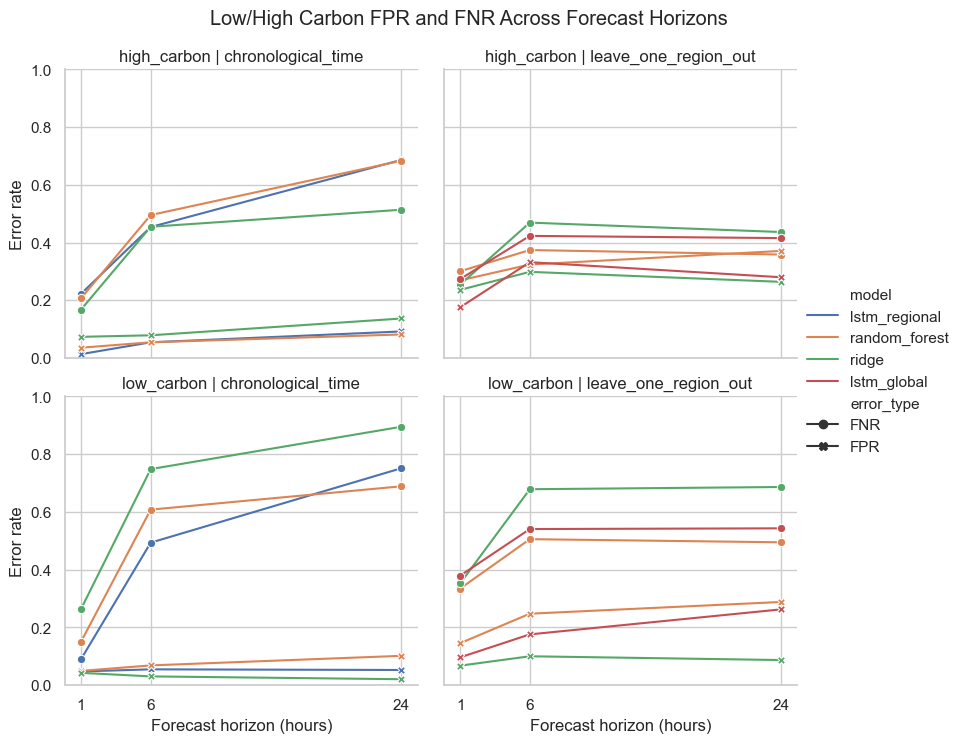

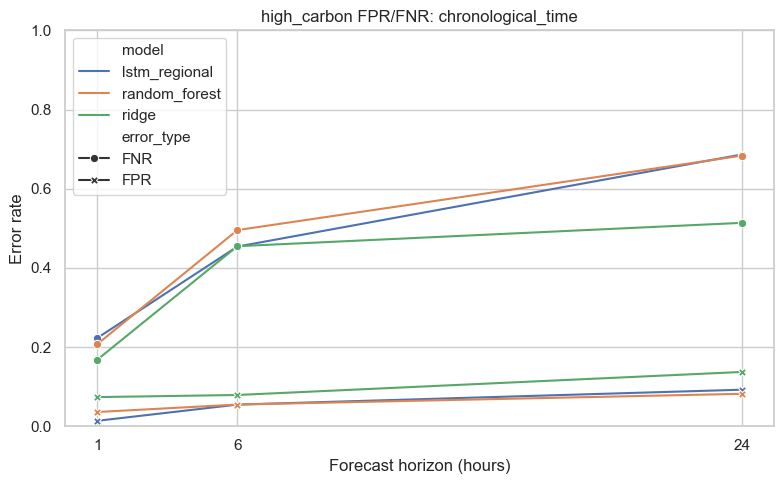

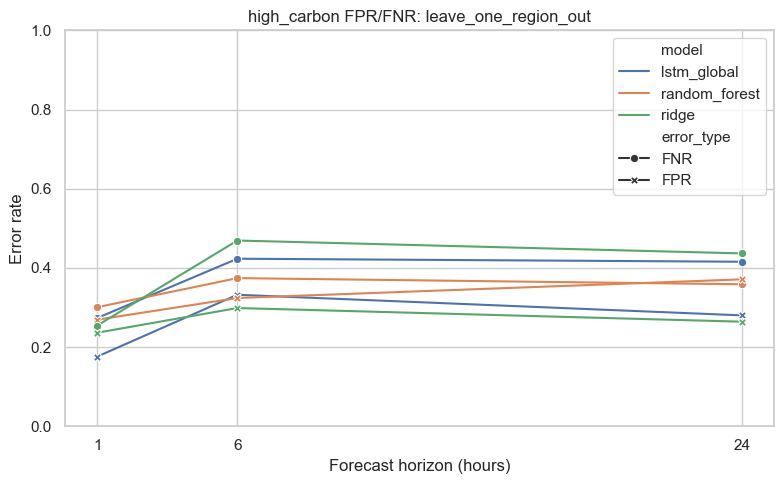

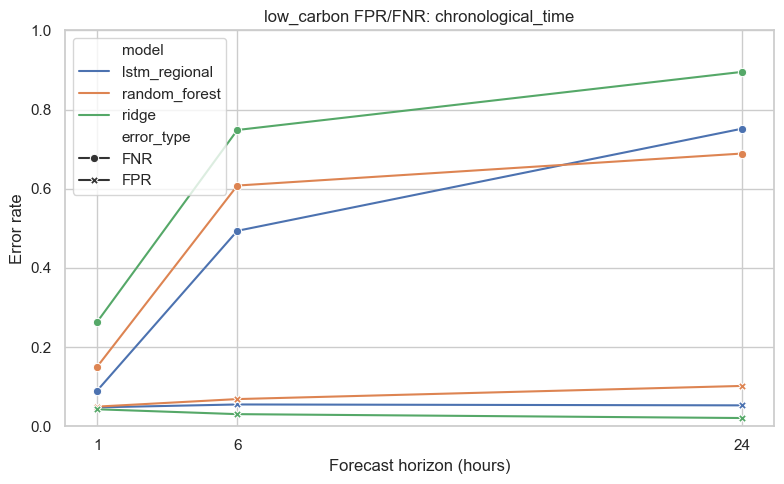

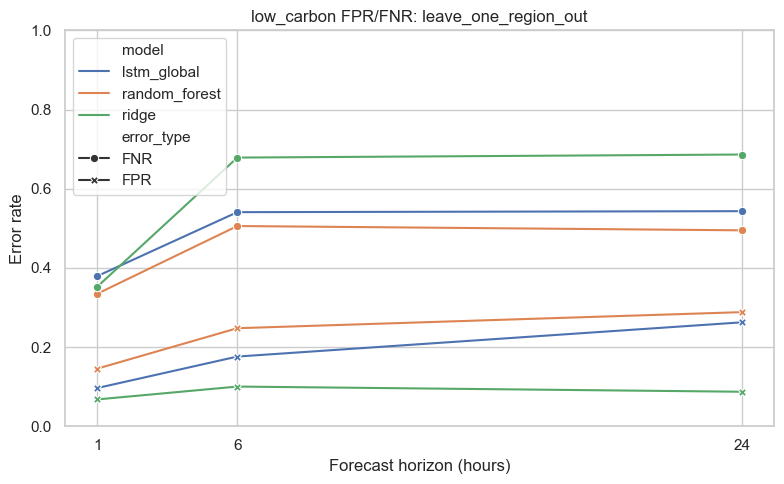

In [8]:
# Plot false-positive and false-negative rates for low/high-carbon event prediction.
fpr_fnr_long = (
    classification_metrics[classification_metrics["region"] == "macro_average"]
    .melt(
        id_vars=["class_label", "split_type", "model", "horizon", "horizon_label"],
        value_vars=["FPR", "FNR"],
        var_name="error_type",
        value_name="rate",
    )
    .sort_values(["class_label", "split_type", "error_type", "horizon", "model"])
    .reset_index(drop=True)
)

if not fpr_fnr_long.empty:
    g = sns.relplot(
        data=fpr_fnr_long,
        x="horizon",
        y="rate",
        hue="model",
        style="error_type",
        row="class_label",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=3.6,
        aspect=1.15,
    )
    g.set_axis_labels("Forecast horizon (hours)", "Error rate")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.suptitle("Low/High Carbon FPR and FNR Across Forecast Horizons", y=1.03)
    for ax in g.axes.flat:
        ax.set_ylim(0, 1)
        ax.set_xticks(HORIZONS)
    plt.show()

    for class_label in sorted(fpr_fnr_long["class_label"].unique()):
        for split_type in sorted(fpr_fnr_long["split_type"].unique()):
            viz = fpr_fnr_long[(fpr_fnr_long["class_label"] == class_label) & (fpr_fnr_long["split_type"] == split_type)]
            if viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.lineplot(
                data=viz,
                x="horizon",
                y="rate",
                hue="model",
                style="error_type",
                markers=True,
                dashes=False,
            )
            plt.title(f"{class_label} FPR/FNR: {split_type}")
            plt.xlabel("Forecast horizon (hours)")
            plt.ylabel("Error rate")
            plt.xticks(HORIZONS)
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()
else:
    print("No FPR/FNR rows available.")


## Generalization Gap

For models with both temporal and leave-one-region-out rows under the same model name, compute `leave_one_region_out_MAE - chronological_time_MAE`. For LSTM, if temporal rows use `lstm_regional` and region-holdout rows use `lstm_global`, the notebook also maps both to the `lstm` family.


In [9]:
# Compare temporal MAE against regional holdout MAE to quantify transfer loss.
def model_family(model):
    if model in {"lstm_regional", "lstm_global"}:
        return "lstm"
    return model


def display_model_name(model_family_name):
    return {
        "lstm": "LSTM",
        "ridge": "Ridge",
        "random_forest": "Random Forest",
    }.get(model_family_name, model_family_name)

metrics_with_family = metrics[metrics["region"] != "macro_average"].copy()
metrics_with_family["model_family"] = metrics_with_family["model"].map(model_family)

temporal = metrics_with_family[metrics_with_family["split_type"] == "chronological_time"].copy()
regional = metrics_with_family[metrics_with_family["split_type"] == "leave_one_region_out"].copy()

gaps = regional.merge(
    temporal,
    on=["model_family", "horizon", "region"],
    suffixes=("_region_holdout", "_temporal"),
)

if not gaps.empty:
    gaps = gaps[["model_family", "horizon", "region", "MAE_temporal", "MAE_region_holdout"]].copy()
    gaps["region_gap"] = gaps["MAE_region_holdout"] - gaps["MAE_temporal"]
    gaps["horizon_label"] = gaps["horizon"].astype(str) + "h"
    gaps["Model"] = gaps["model_family"].map(display_model_name)
    gaps["Region"] = gaps["region"].str.title()

    macro_gaps = gaps.groupby(["model_family", "Model", "horizon", "horizon_label"], as_index=False).agg(
        MAE_temporal=("MAE_temporal", "mean"),
        MAE_region_holdout=("MAE_region_holdout", "mean"),
        region_gap=("region_gap", "mean"),
    )
    macro_gaps["region"] = "macro_average"

    macro_gap_table = (
        macro_gaps.rename(columns={
            "horizon_label": "Horizon",
            "MAE_temporal": "Chronological MAE",
            "MAE_region_holdout": "Regional Holdout MAE",
            "region_gap": "Difference",
        })[["Model", "Horizon", "Chronological MAE", "Regional Holdout MAE", "Difference"]]
        .sort_values(["Horizon", "Model"])
        .reset_index(drop=True)
    )

    region_gap_table = (
        gaps.rename(columns={
            "horizon_label": "Horizon",
            "MAE_temporal": "Chronological MAE",
            "MAE_region_holdout": "Regional Holdout MAE",
            "region_gap": "Difference",
        })[["Region", "Model", "Horizon", "Chronological MAE", "Regional Holdout MAE", "Difference"]]
        .sort_values(["Region", "Horizon", "Model"])
        .reset_index(drop=True)
    )

    print("Macro MAE difference: regional holdout minus chronological")
    display(macro_gap_table.style.format({
        "Chronological MAE": "{:.2f}",
        "Regional Holdout MAE": "{:.2f}",
        "Difference": "{:+.2f}",
    }).hide(axis="index"))

    print("Region-specific MAE difference: regional holdout minus chronological")
    display(region_gap_table.style.format({
        "Chronological MAE": "{:.2f}",
        "Regional Holdout MAE": "{:.2f}",
        "Difference": "{:+.2f}",
    }).hide(axis="index"))
else:
    print("No models currently have both temporal and regional rows for gap computation.")
    macro_gaps = pd.DataFrame()
    macro_gap_table = pd.DataFrame()
    region_gap_table = pd.DataFrame()


Macro MAE difference: regional holdout minus chronological


Model,Horizon,Chronological MAE,Regional Holdout MAE,Difference
LSTM,1h,11.88,31.13,+19.26
Random Forest,1h,13.08,51.84,+38.76
Ridge,1h,15.07,28.50,+13.43
LSTM,24h,37.52,64.34,+26.82
Random Forest,24h,38.02,68.22,+30.19
Ridge,24h,35.41,44.67,+9.26
LSTM,6h,25.52,61.07,+35.56
Random Forest,6h,27.43,65.22,+37.78
Ridge,6h,30.40,50.68,+20.28


Region-specific MAE difference: regional holdout minus chronological


Region,Model,Horizon,Chronological MAE,Regional Holdout MAE,Difference
California,LSTM,1h,15.59,32.61,+17.02
California,Random Forest,1h,10.61,79.52,+68.90
California,Ridge,1h,12.90,22.34,+9.45
California,LSTM,24h,27.08,81.39,+54.31
California,Random Forest,24h,21.75,96.84,+75.08
California,Ridge,24h,19.79,42.36,+22.57
California,LSTM,6h,20.48,101.45,+80.97
California,Random Forest,6h,21.99,97.73,+75.74
California,Ridge,6h,29.06,59.84,+30.78
Illinois,LSTM,1h,7.39,50.39,+43.00


## Graph: MAE By Model And Horizon

This is the main absolute-error comparison. Lower MAE means the model's forecast is closer to the actual carbon intensity in `gCO2eq/kWh`; the panel compares the standard chronological forecast setting against the harder leave-one-region-out setting.

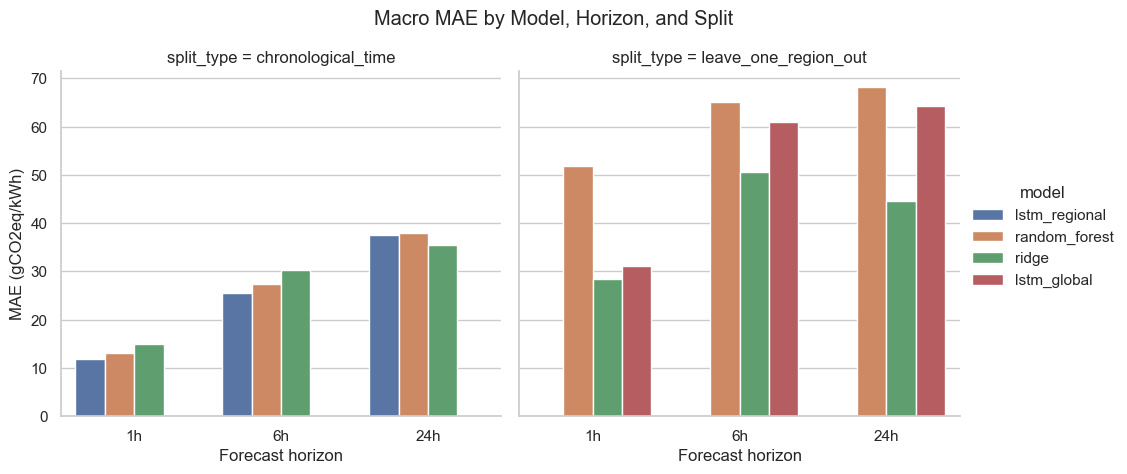

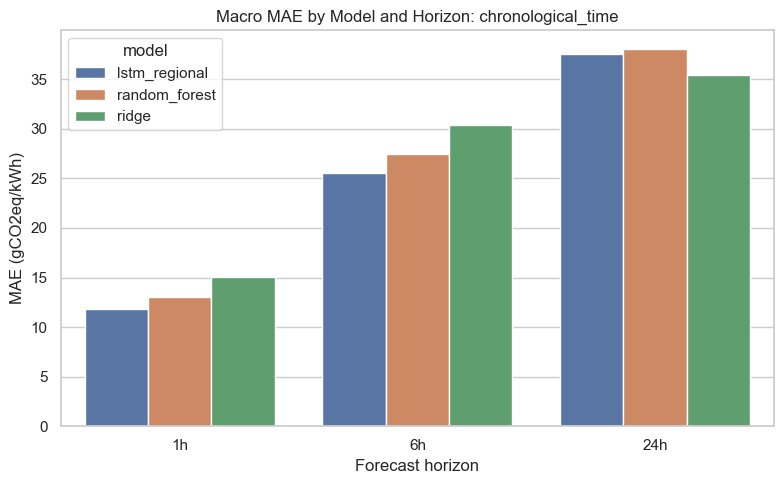

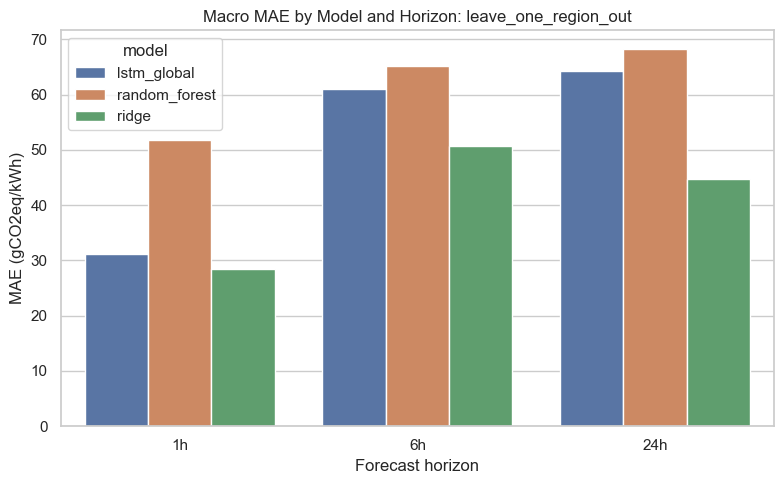

In [10]:
# Plot macro MAE panels plus individual split-specific versions.
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.catplot(
        data=macro,
        x="horizon_label",
        y="MAE",
        hue="model",
        col="split_type",
        kind="bar",
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon", f"MAE ({UNIT})")
    g.fig.suptitle("Macro MAE by Model, Horizon, and Split", y=1.05)
    plt.show()

    for split_type in sorted(macro["split_type"].unique()):
        viz = macro[macro["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.barplot(data=viz, x="horizon_label", y="MAE", hue="model")
        plt.title(f"Macro MAE by Model and Horizon: {split_type}")
        plt.xlabel("Forecast horizon")
        plt.ylabel(f"MAE ({UNIT})")
        plt.tight_layout()
        plt.show()


## Graph: R2 By Model And Horizon

R2 is computed with the same grouping as MAE. Higher is better; values below zero mean the model is worse than predicting the mean for that evaluation group.

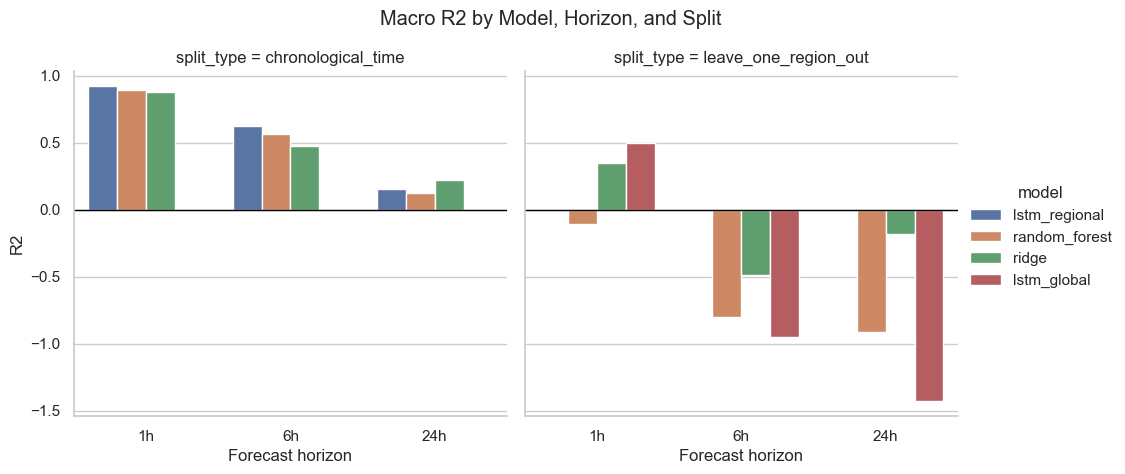

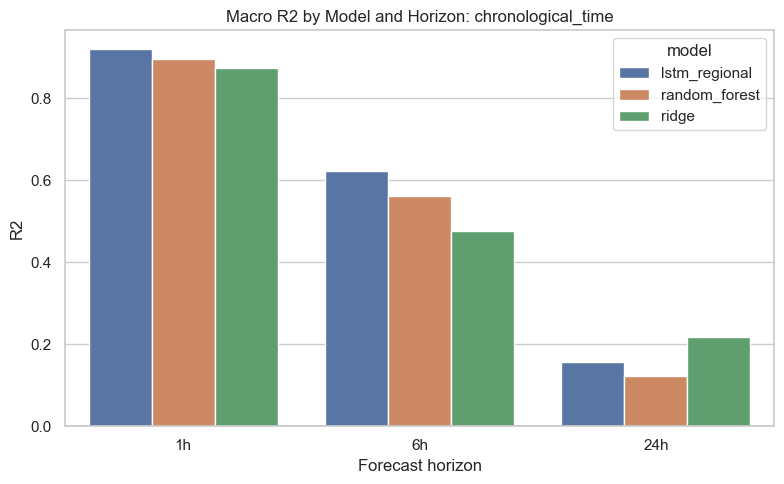

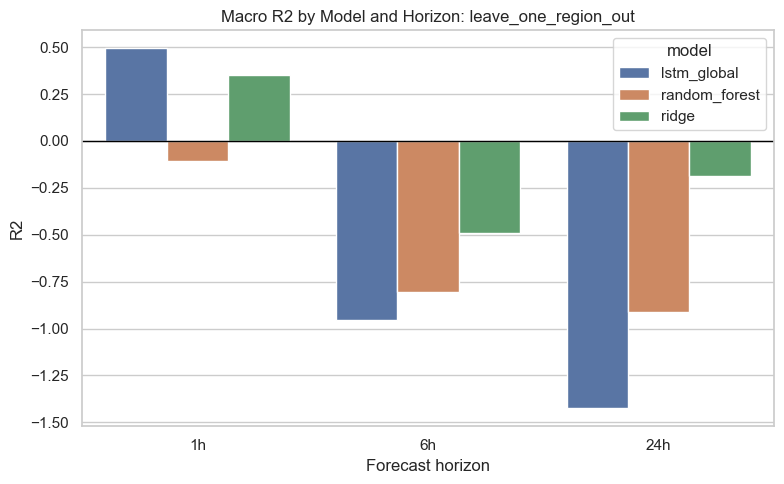

In [11]:
# Plot macro R2 panels plus individual split-specific versions.
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.catplot(
        data=macro,
        x="horizon_label",
        y="R2",
        hue="model",
        col="split_type",
        kind="bar",
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon", "R2")
    g.fig.suptitle("Macro R2 by Model, Horizon, and Split", y=1.05)
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
    plt.show()

    for split_type in sorted(macro["split_type"].unique()):
        viz = macro[macro["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.barplot(data=viz, x="horizon_label", y="R2", hue="model")
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"Macro R2 by Model and Horizon: {split_type}")
        plt.xlabel("Forecast horizon")
        plt.ylabel("R2")
        plt.tight_layout()
        plt.show()


## Graph: Horizon Trend Lines

These line charts show how macro-average MAE and R2 change as the forecast horizon gets farther out.

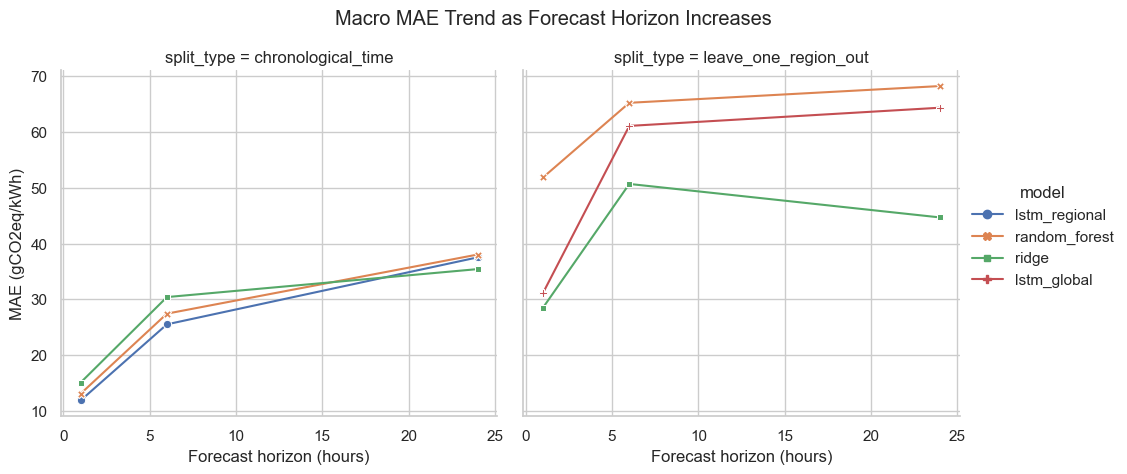

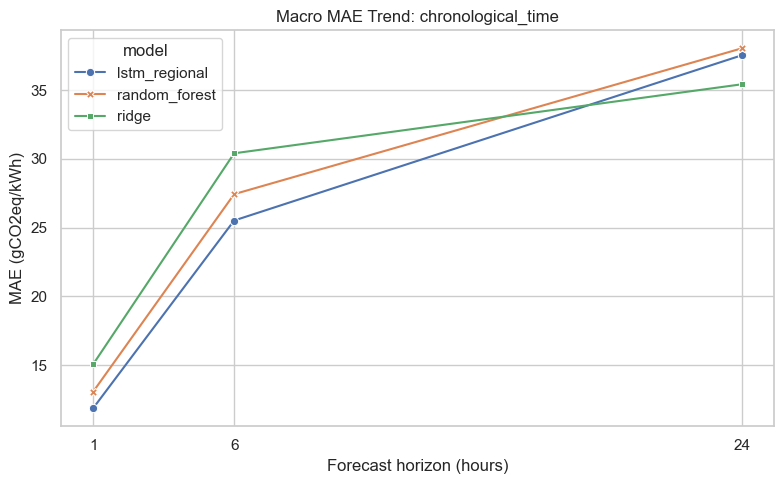

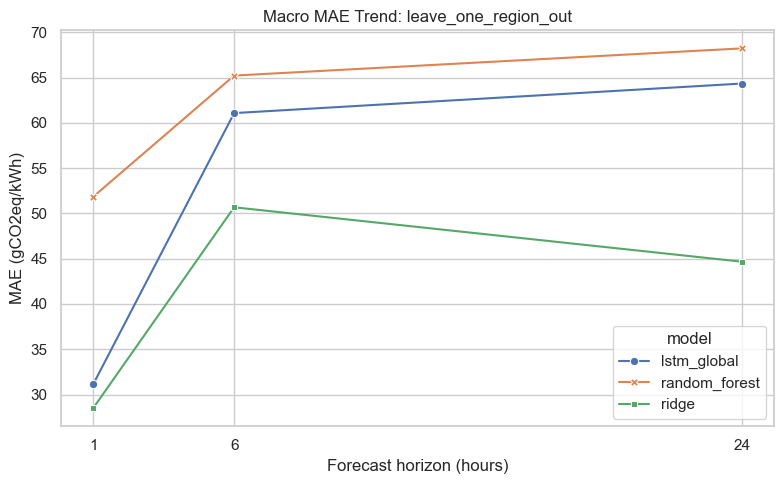

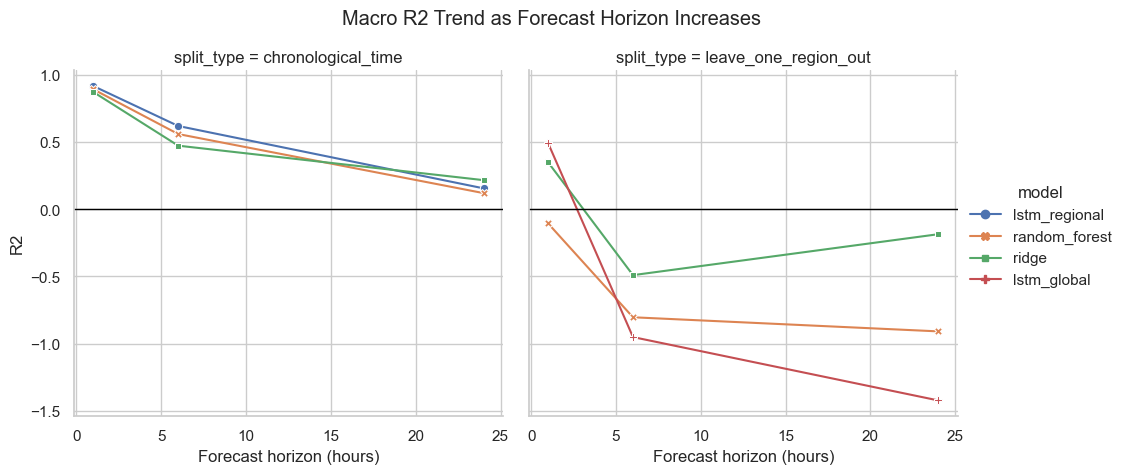

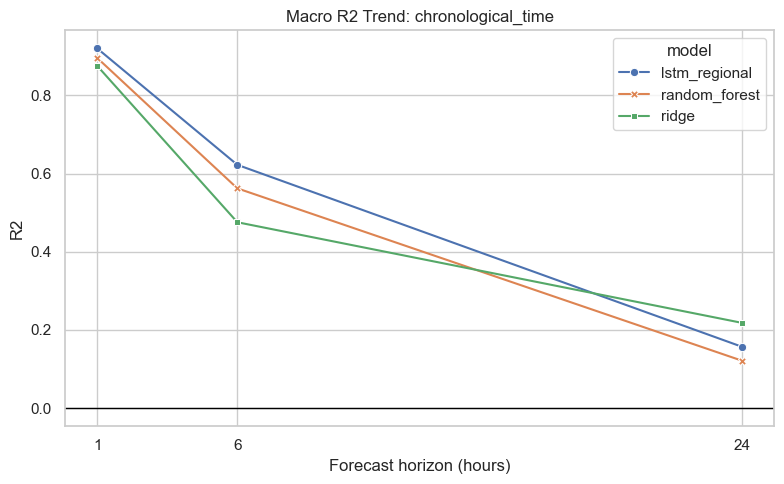

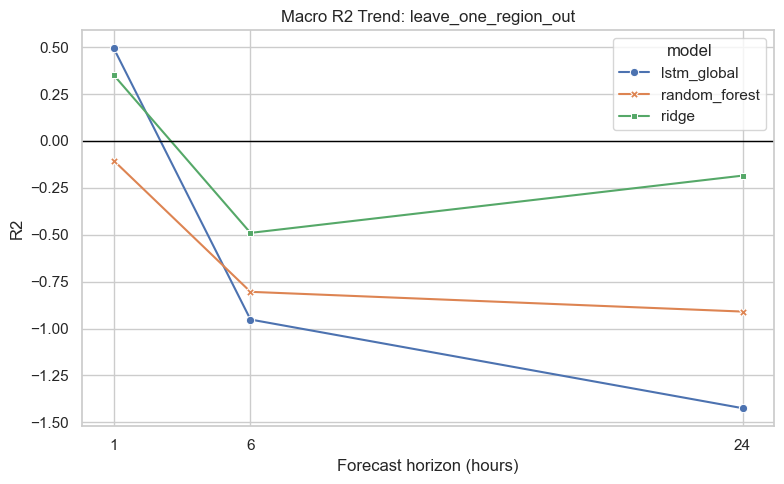

In [12]:
# Plot horizon trends for macro MAE and R2.
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.relplot(
        data=macro,
        x="horizon",
        y="MAE",
        hue="model",
        style="model",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon (hours)", f"MAE ({UNIT})")
    g.fig.suptitle("Macro MAE Trend as Forecast Horizon Increases", y=1.05)
    plt.show()

    for split_type in sorted(macro["split_type"].unique()):
        viz = macro[macro["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.lineplot(
            data=viz,
            x="horizon",
            y="MAE",
            hue="model",
            style="model",
            markers=True,
            dashes=False,
        )
        plt.title(f"Macro MAE Trend: {split_type}")
        plt.xlabel("Forecast horizon (hours)")
        plt.ylabel(f"MAE ({UNIT})")
        plt.xticks(HORIZONS)
        plt.tight_layout()
        plt.show()

    g = sns.relplot(
        data=macro,
        x="horizon",
        y="R2",
        hue="model",
        style="model",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon (hours)", "R2")
    g.fig.suptitle("Macro R2 Trend as Forecast Horizon Increases", y=1.05)
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
    plt.show()

    for split_type in sorted(macro["split_type"].unique()):
        viz = macro[macro["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.lineplot(
            data=viz,
            x="horizon",
            y="R2",
            hue="model",
            style="model",
            markers=True,
            dashes=False,
        )
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"Macro R2 Trend: {split_type}")
        plt.xlabel("Forecast horizon (hours)")
        plt.ylabel("R2")
        plt.xticks(HORIZONS)
        plt.tight_layout()
        plt.show()


## Graph: Peak-Period Error

These plots focus only on the highest-carbon hours, defined as the top 10% within each region. They show whether a model still performs well during the grid conditions that matter most for climate-aware scheduling.

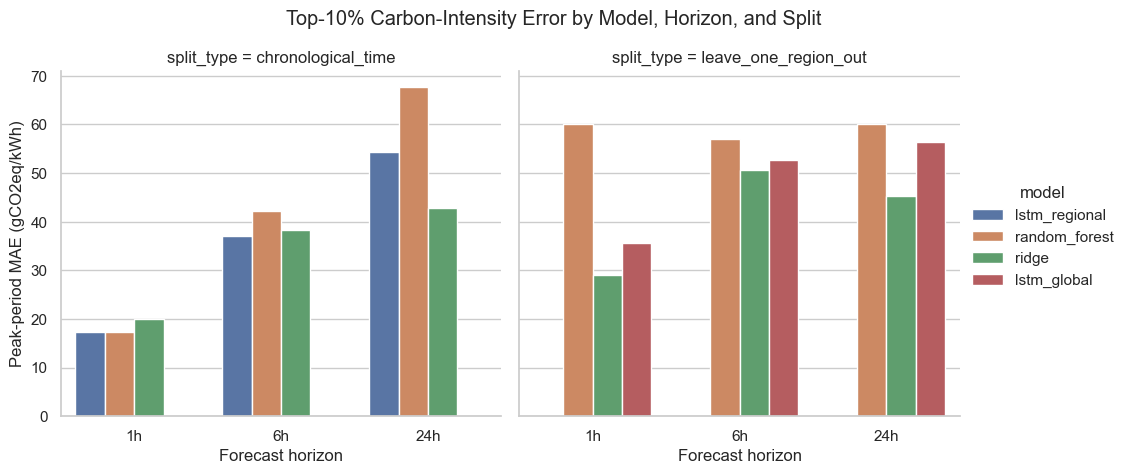

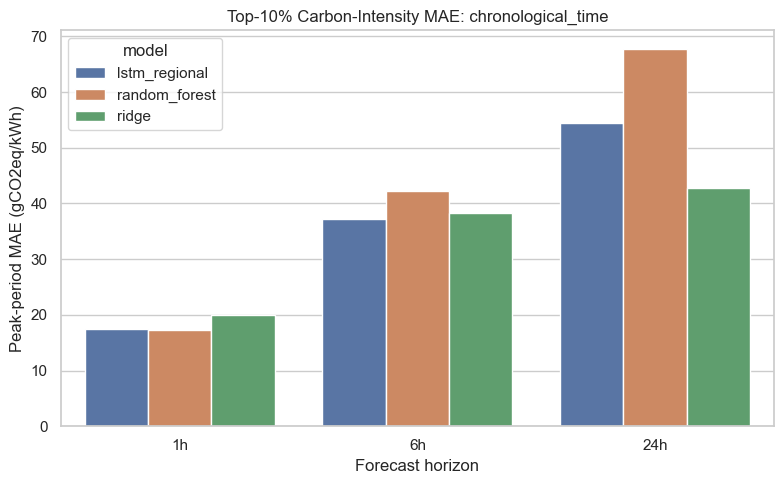

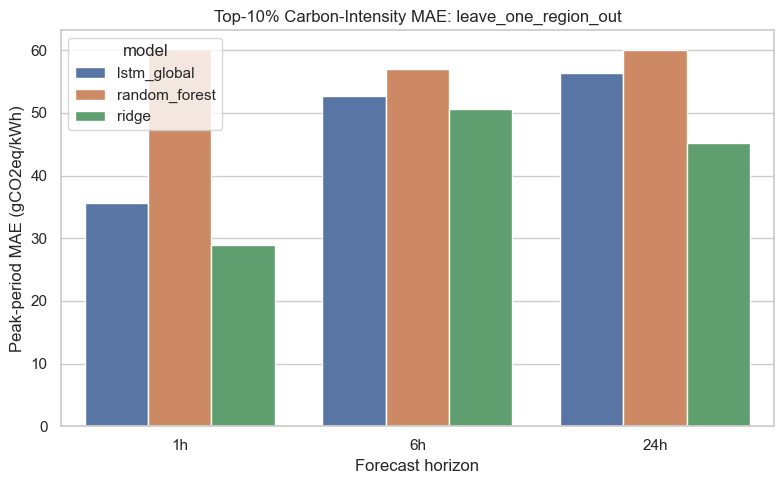

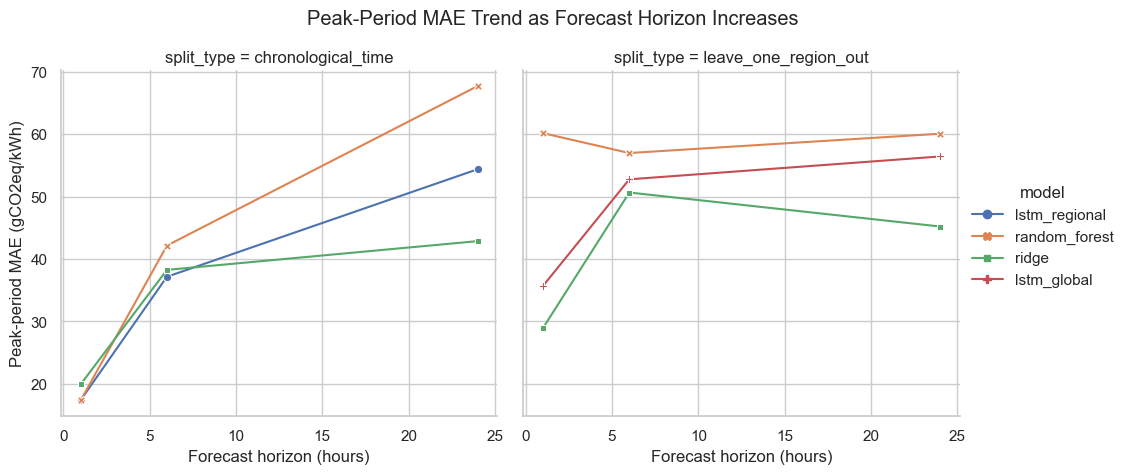

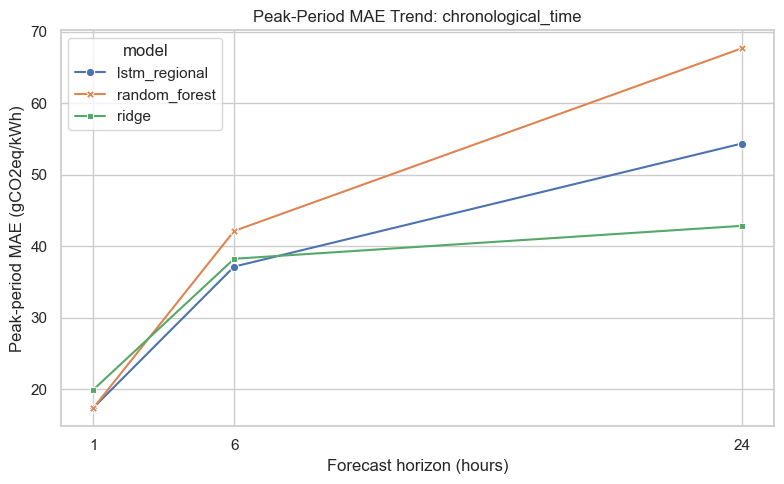

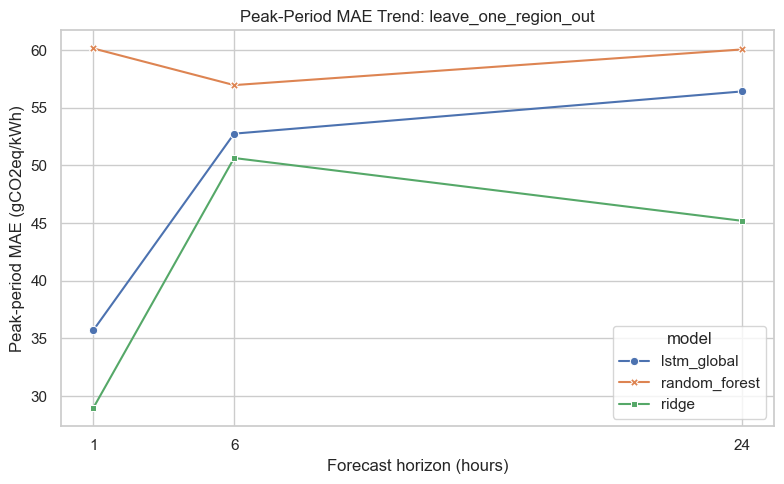

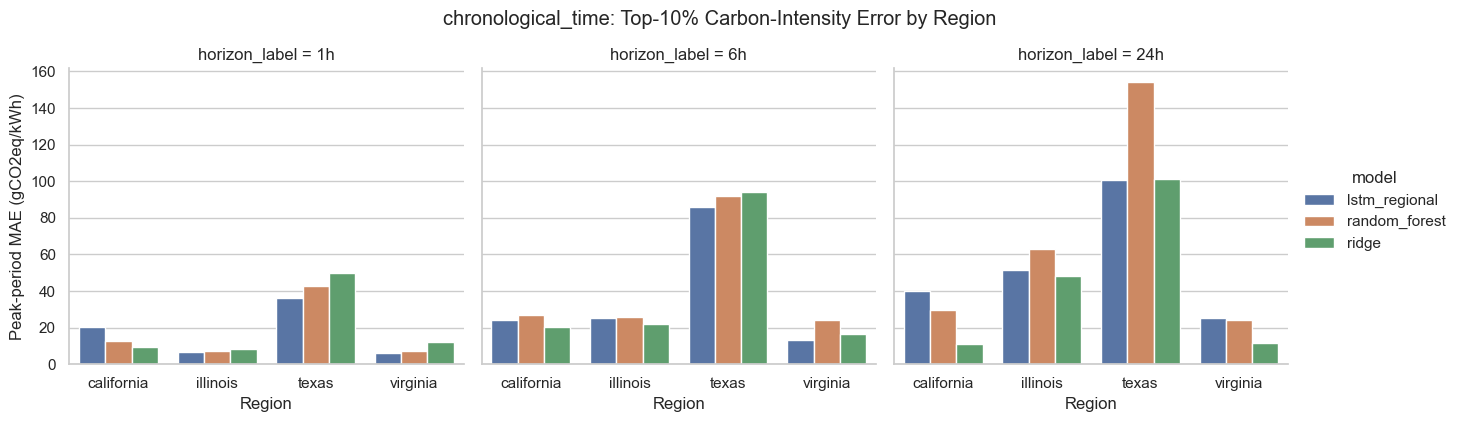

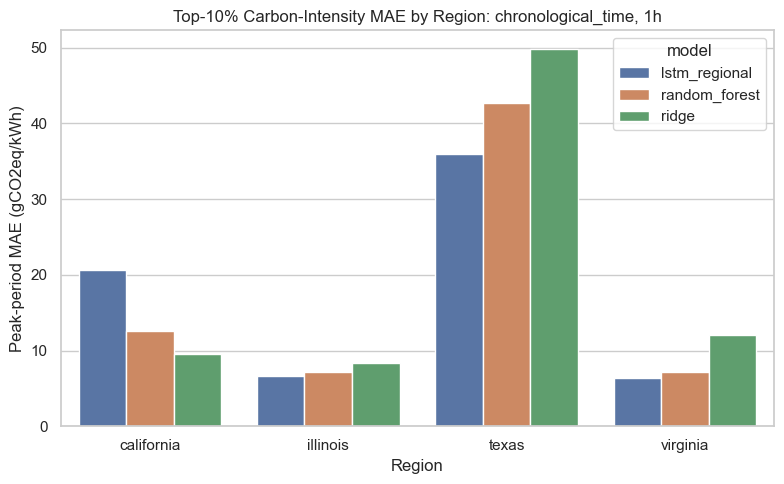

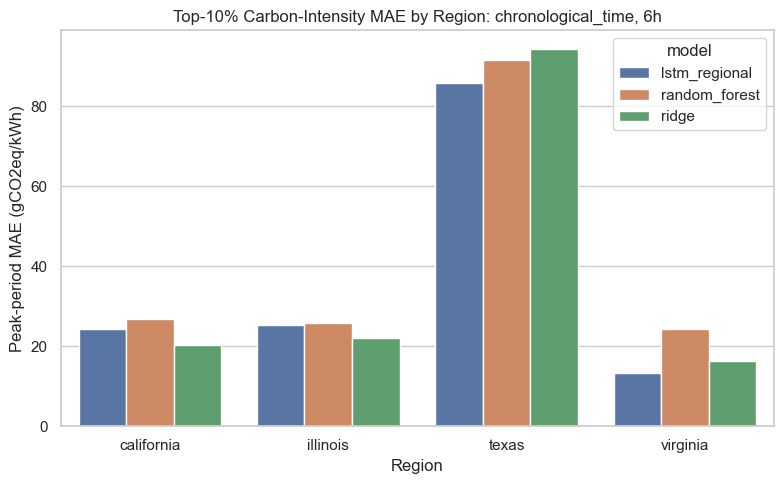

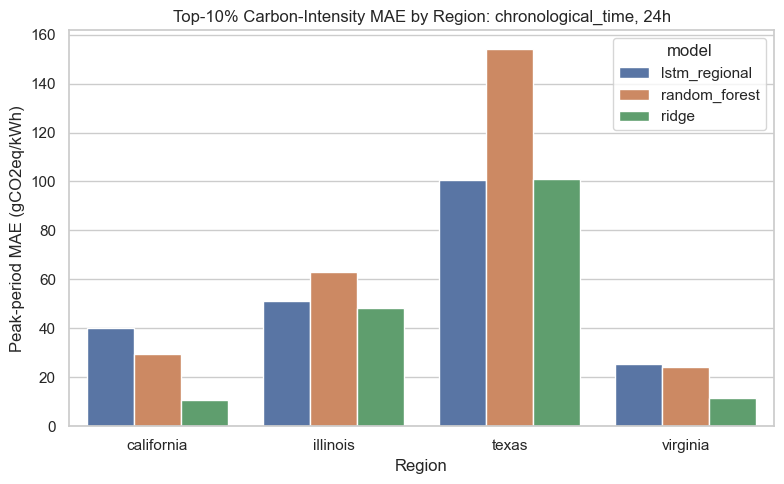

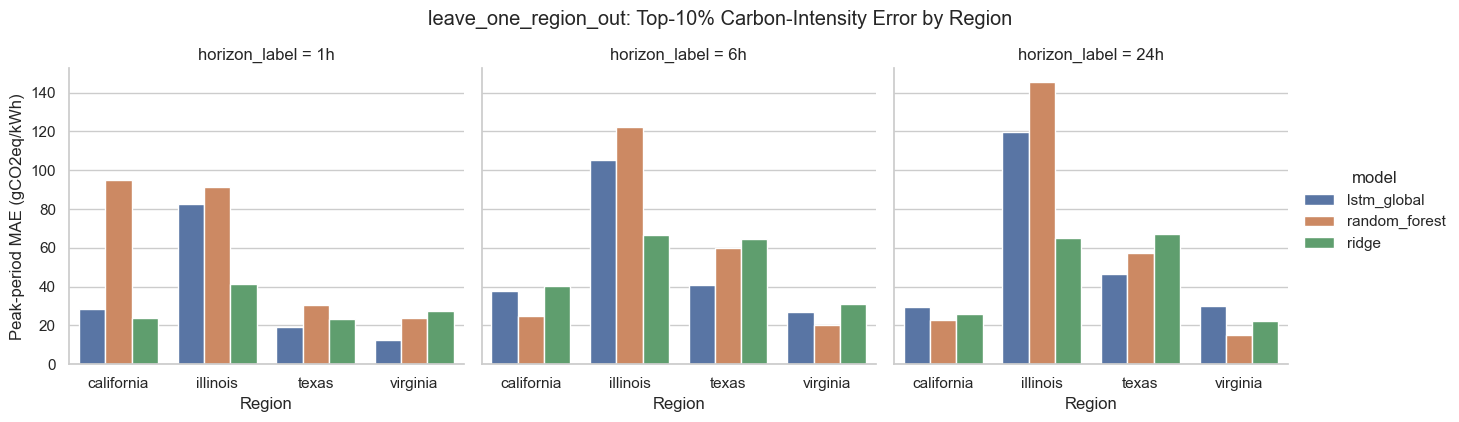

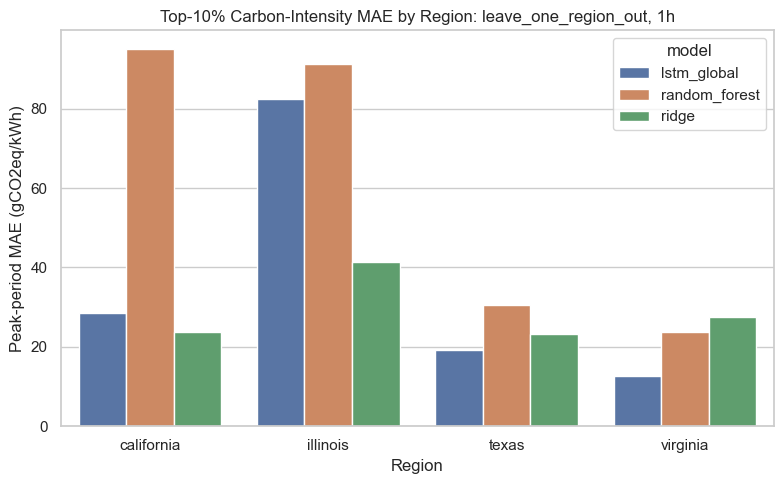

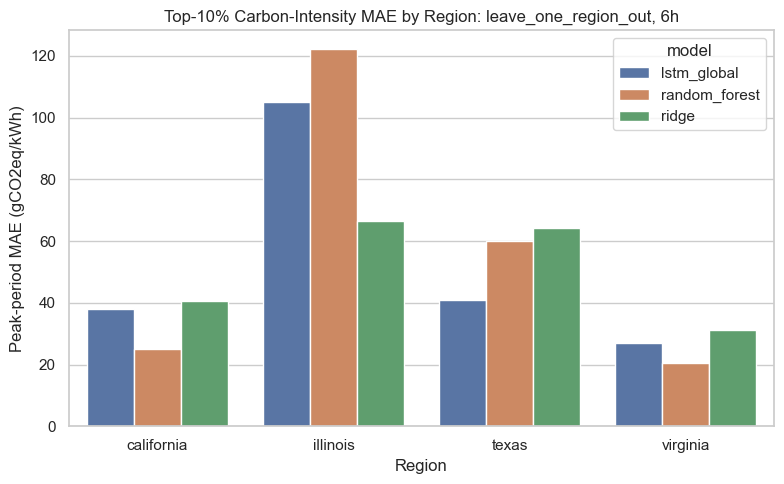

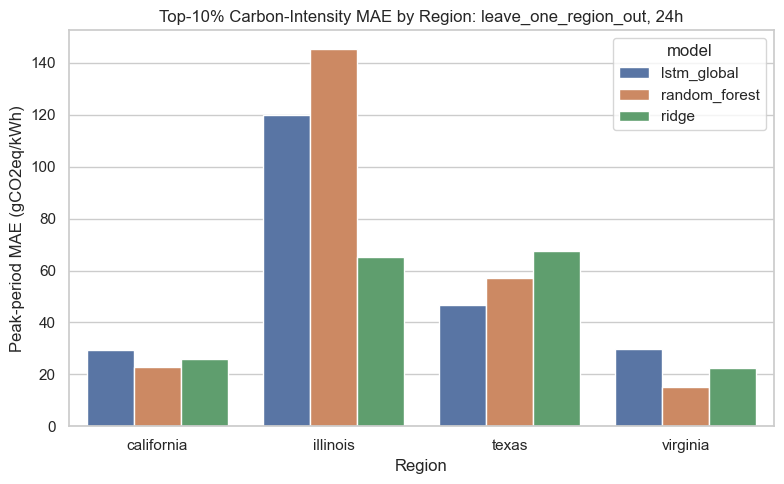

In [13]:
# Plot model performance during top-10% carbon-intensity periods.
macro_peak = peak_metrics[peak_metrics["region"] == "macro_average"].copy()
if not macro_peak.empty:
    g = sns.catplot(
        data=macro_peak,
        x="horizon_label",
        y="MAE",
        hue="model",
        col="split_type",
        kind="bar",
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon", f"Peak-period MAE ({UNIT})")
    g.fig.suptitle("Top-10% Carbon-Intensity Error by Model, Horizon, and Split", y=1.05)
    plt.show()

    for split_type in sorted(macro_peak["split_type"].unique()):
        viz = macro_peak[macro_peak["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.barplot(data=viz, x="horizon_label", y="MAE", hue="model")
        plt.title(f"Top-10% Carbon-Intensity MAE: {split_type}")
        plt.xlabel("Forecast horizon")
        plt.ylabel(f"Peak-period MAE ({UNIT})")
        plt.tight_layout()
        plt.show()

    g = sns.relplot(
        data=macro_peak,
        x="horizon",
        y="MAE",
        hue="model",
        style="model",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon (hours)", f"Peak-period MAE ({UNIT})")
    g.fig.suptitle("Peak-Period MAE Trend as Forecast Horizon Increases", y=1.05)
    plt.show()

    for split_type in sorted(macro_peak["split_type"].unique()):
        viz = macro_peak[macro_peak["split_type"] == split_type]
        plt.figure(figsize=(8, 5))
        sns.lineplot(
            data=viz,
            x="horizon",
            y="MAE",
            hue="model",
            style="model",
            markers=True,
            dashes=False,
        )
        plt.title(f"Peak-Period MAE Trend: {split_type}")
        plt.xlabel("Forecast horizon (hours)")
        plt.ylabel(f"Peak-period MAE ({UNIT})")
        plt.xticks(HORIZONS)
        plt.tight_layout()
        plt.show()
else:
    print("No peak-period rows available.")

region_peak = peak_metrics[peak_metrics["region"] != "macro_average"].copy()
if not region_peak.empty:
    for split_type in sorted(region_peak["split_type"].unique()):
        viz = region_peak[region_peak["split_type"] == split_type]
        g = sns.catplot(
            data=viz,
            x="region",
            y="MAE",
            hue="model",
            col="horizon_label",
            kind="bar",
            height=4,
            aspect=1.1,
        )
        g.set_axis_labels("Region", f"Peak-period MAE ({UNIT})")
        g.fig.suptitle(f"{split_type}: Top-10% Carbon-Intensity Error by Region", y=1.05)
        plt.show()

        for horizon in HORIZONS:
            horizon_viz = viz[viz["horizon"] == horizon]
            if horizon_viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.barplot(data=horizon_viz, x="region", y="MAE", hue="model")
            plt.title(f"Top-10% Carbon-Intensity MAE by Region: {split_type}, {horizon}h")
            plt.xlabel("Region")
            plt.ylabel(f"Peak-period MAE ({UNIT})")
            plt.tight_layout()
            plt.show()


## Graph: Low/High Carbon Classification

These plots convert the regression forecasts into decision-oriented labels. Low carbon means below the region's 25th percentile and high carbon means above the region's 75th percentile; accuracy and F1 show whether the model can identify useful scheduling windows.

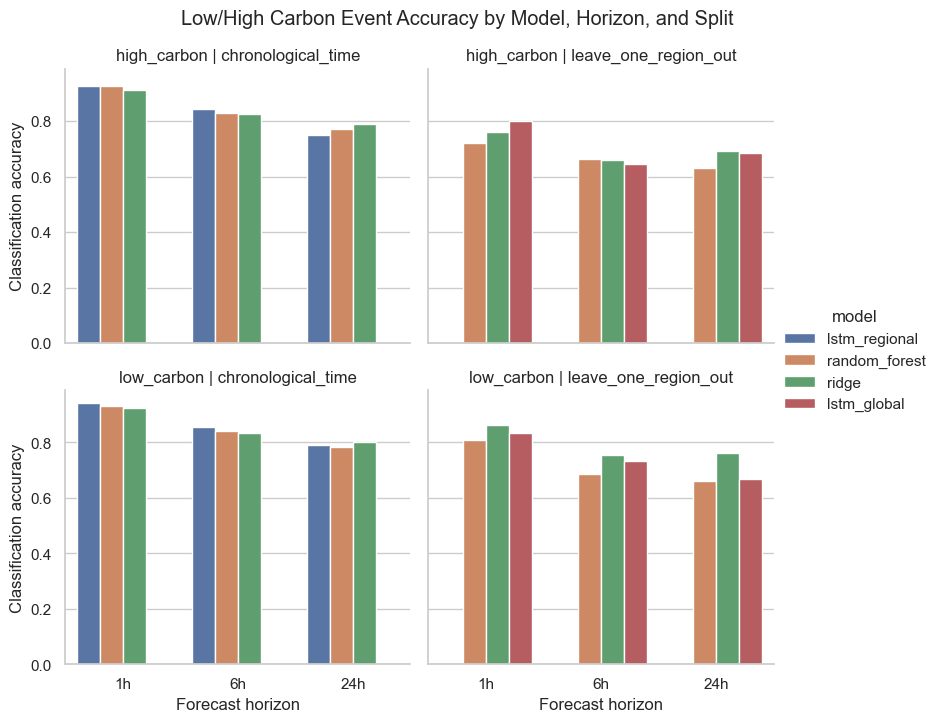

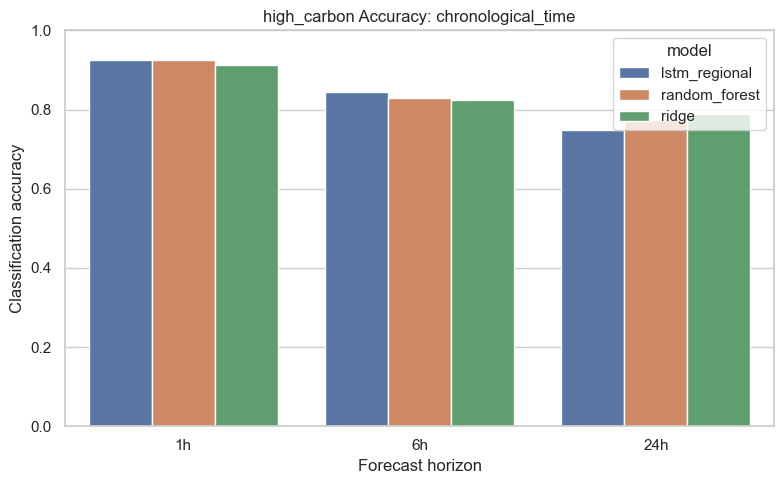

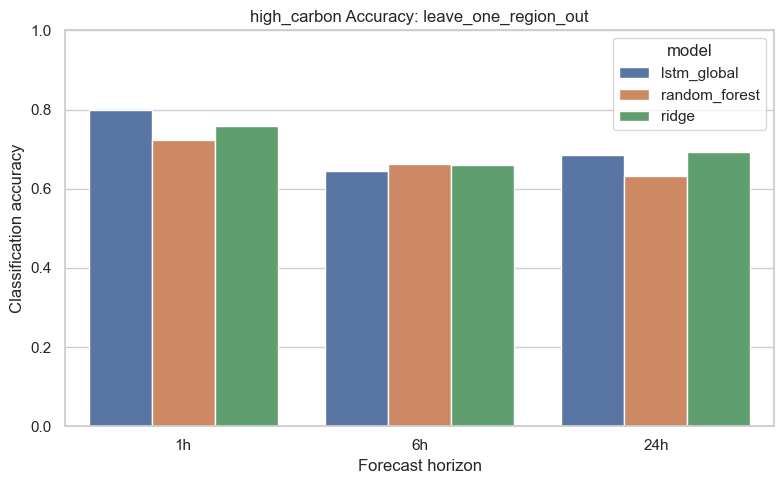

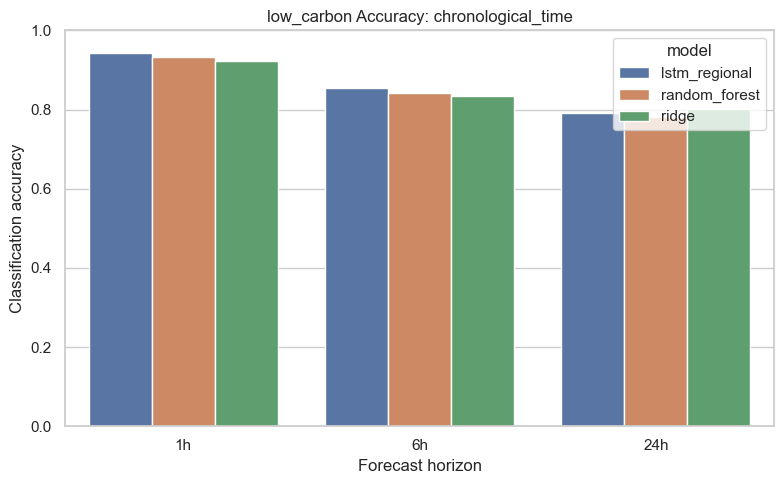

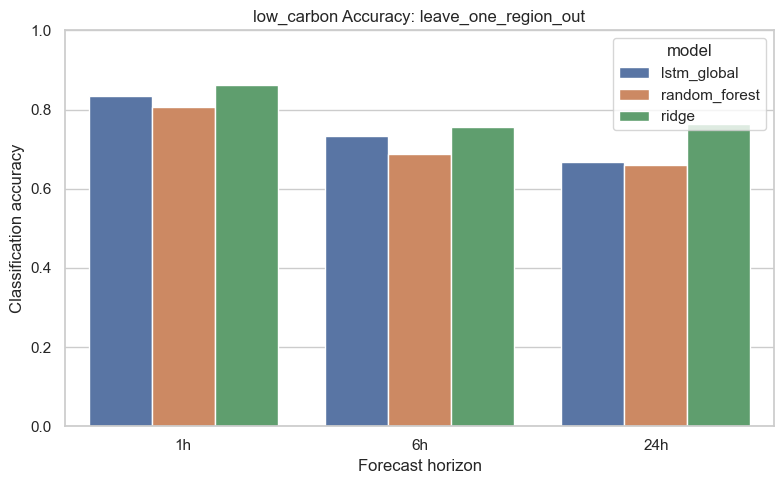

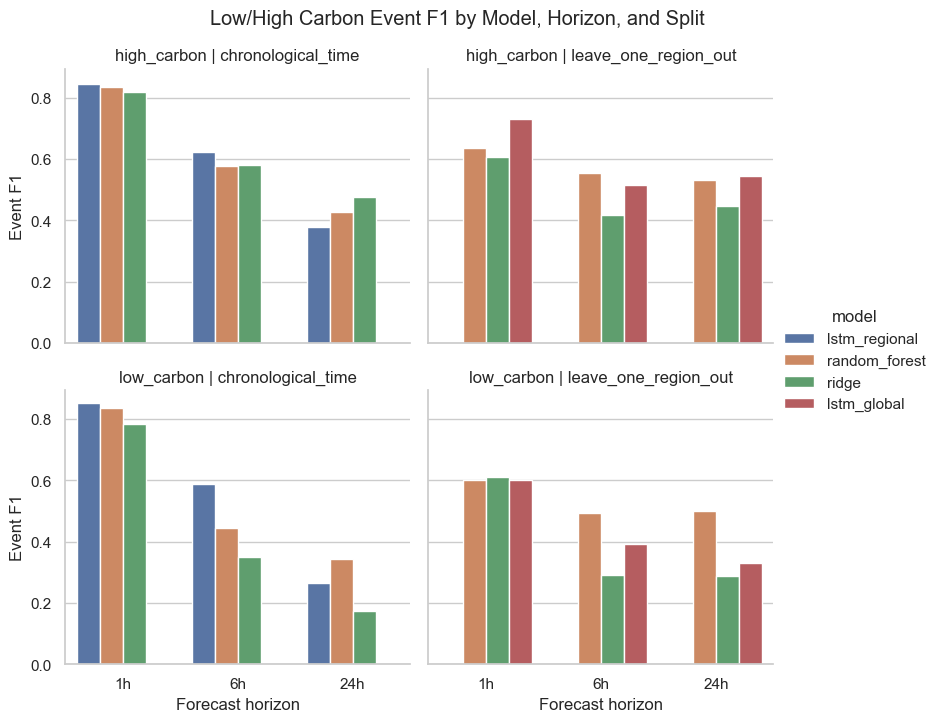

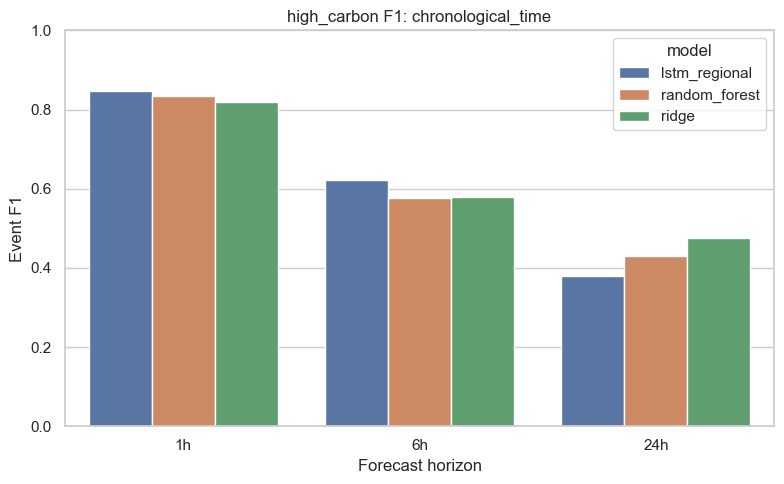

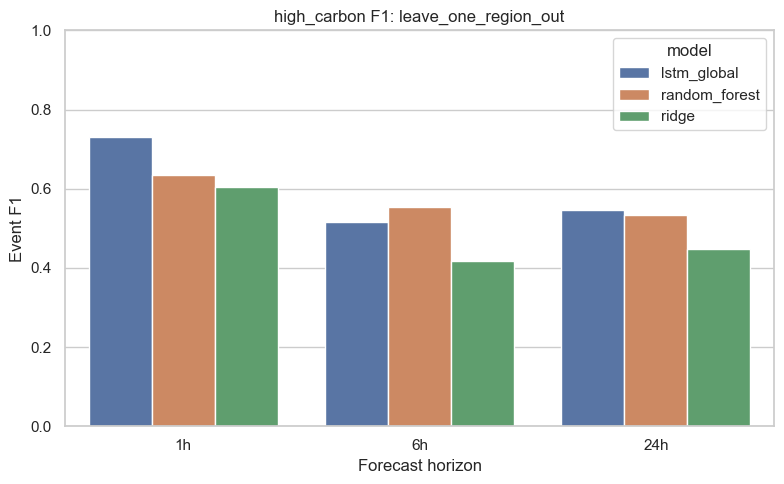

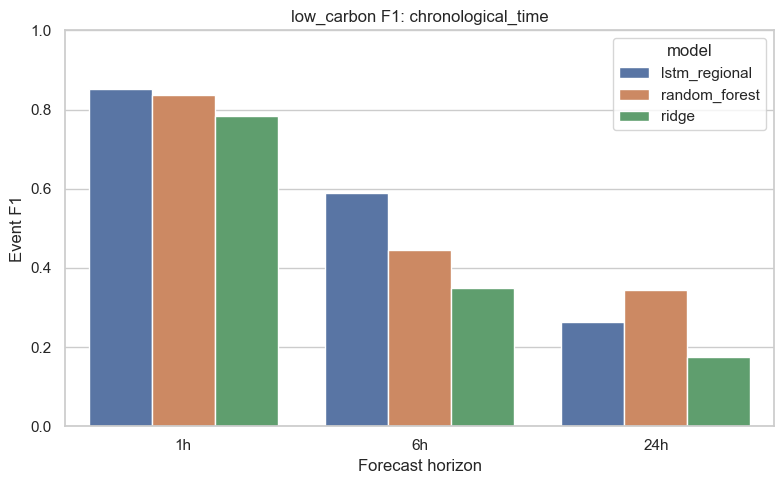

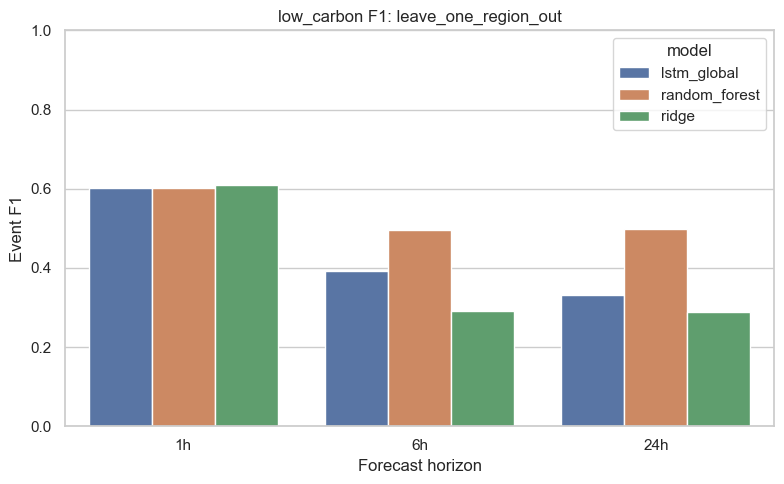

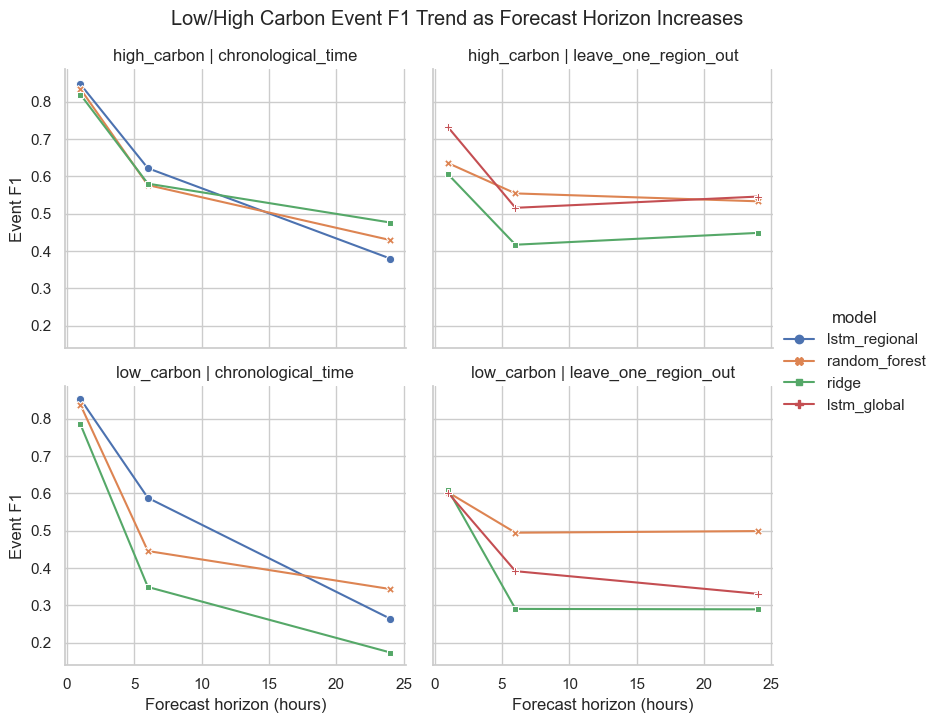

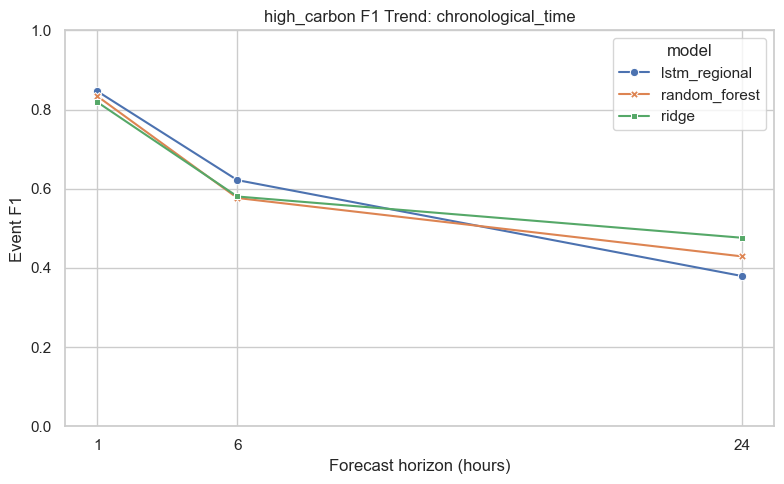

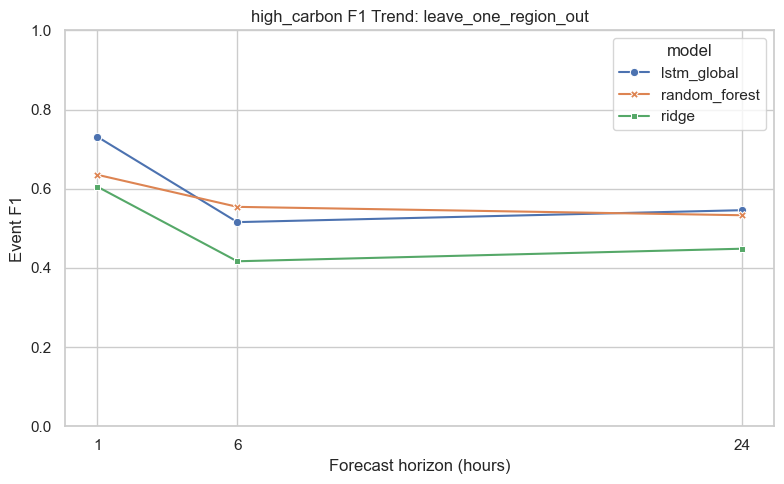

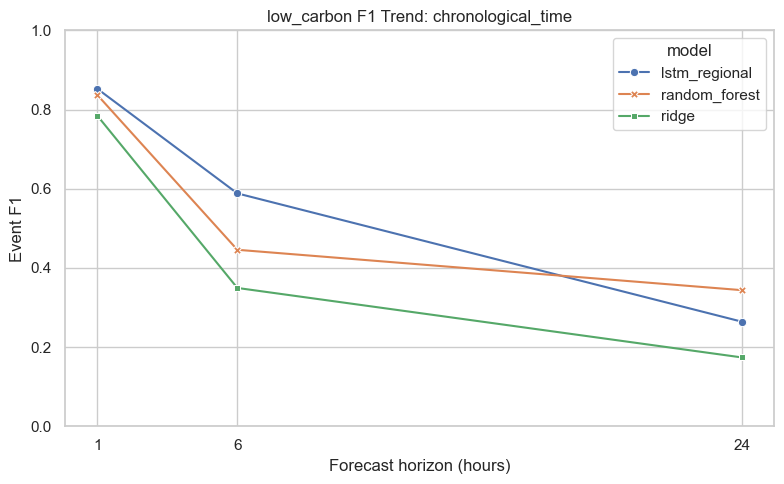

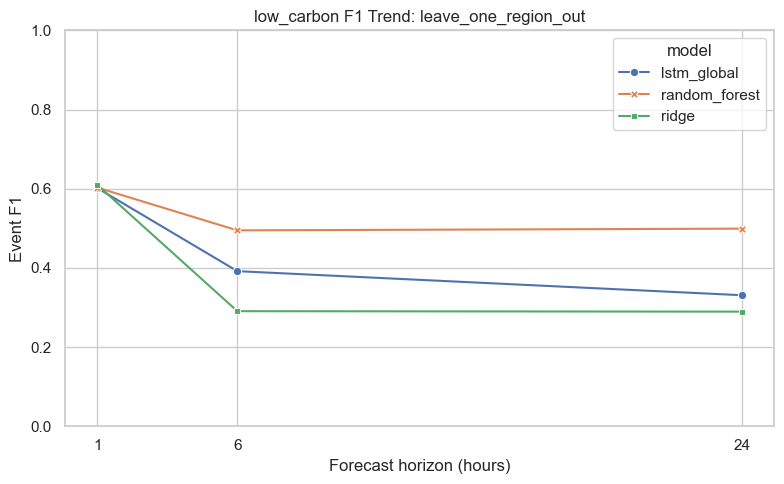

In [14]:
# Plot low/high-carbon classification accuracy and F1.
macro_class = classification_metrics[classification_metrics["region"] == "macro_average"].copy()
if not macro_class.empty:
    g = sns.catplot(
        data=macro_class,
        x="horizon_label",
        y="accuracy",
        hue="model",
        row="class_label",
        col="split_type",
        kind="bar",
        height=3.5,
        aspect=1.15,
        sharey=True,
    )
    g.set_axis_labels("Forecast horizon", "Classification accuracy")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.suptitle("Low/High Carbon Event Accuracy by Model, Horizon, and Split", y=1.03)
    plt.show()

    for class_label in sorted(macro_class["class_label"].unique()):
        for split_type in sorted(macro_class["split_type"].unique()):
            viz = macro_class[(macro_class["class_label"] == class_label) & (macro_class["split_type"] == split_type)]
            if viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.barplot(data=viz, x="horizon_label", y="accuracy", hue="model")
            plt.title(f"{class_label} Accuracy: {split_type}")
            plt.xlabel("Forecast horizon")
            plt.ylabel("Classification accuracy")
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()

    g = sns.catplot(
        data=macro_class,
        x="horizon_label",
        y="F1",
        hue="model",
        row="class_label",
        col="split_type",
        kind="bar",
        height=3.5,
        aspect=1.15,
        sharey=True,
    )
    g.set_axis_labels("Forecast horizon", "Event F1")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.suptitle("Low/High Carbon Event F1 by Model, Horizon, and Split", y=1.03)
    plt.show()

    for class_label in sorted(macro_class["class_label"].unique()):
        for split_type in sorted(macro_class["split_type"].unique()):
            viz = macro_class[(macro_class["class_label"] == class_label) & (macro_class["split_type"] == split_type)]
            if viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.barplot(data=viz, x="horizon_label", y="F1", hue="model")
            plt.title(f"{class_label} F1: {split_type}")
            plt.xlabel("Forecast horizon")
            plt.ylabel("Event F1")
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()

    g = sns.relplot(
        data=macro_class,
        x="horizon",
        y="F1",
        hue="model",
        style="model",
        row="class_label",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=3.5,
        aspect=1.15,
    )
    g.set_axis_labels("Forecast horizon (hours)", "Event F1")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.suptitle("Low/High Carbon Event F1 Trend as Forecast Horizon Increases", y=1.03)
    plt.show()

    for class_label in sorted(macro_class["class_label"].unique()):
        for split_type in sorted(macro_class["split_type"].unique()):
            viz = macro_class[(macro_class["class_label"] == class_label) & (macro_class["split_type"] == split_type)]
            if viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.lineplot(
                data=viz,
                x="horizon",
                y="F1",
                hue="model",
                style="model",
                markers=True,
                dashes=False,
            )
            plt.title(f"{class_label} F1 Trend: {split_type}")
            plt.xlabel("Forecast horizon (hours)")
            plt.ylabel("Event F1")
            plt.xticks(HORIZONS)
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()
else:
    print("No classification rows available.")


## Graph: MAE By Region

This breaks MAE down by region so regional failure modes are visible. In the chronological panel, each bar is a model's error on that region's future test period; in the leave-one-region-out panel, each region was completely held out from training.

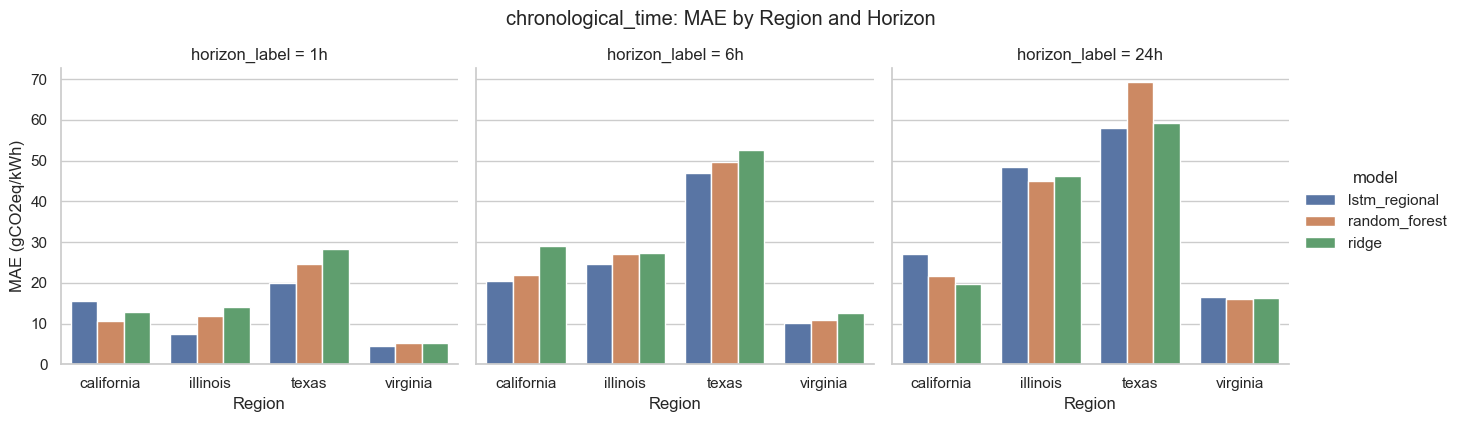

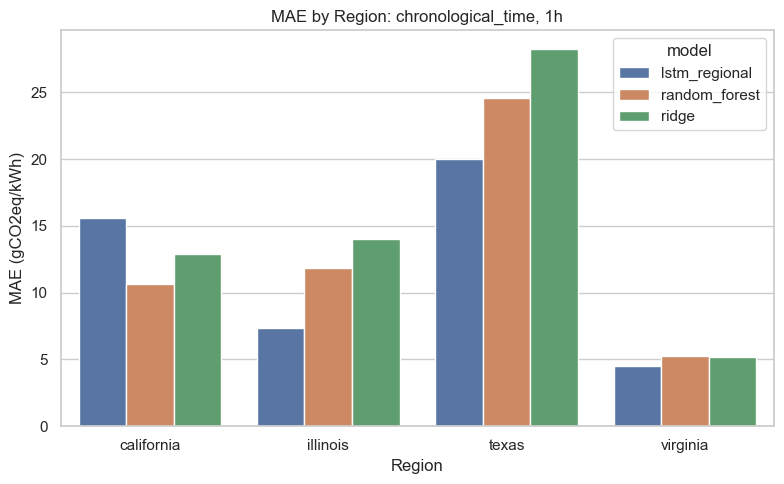

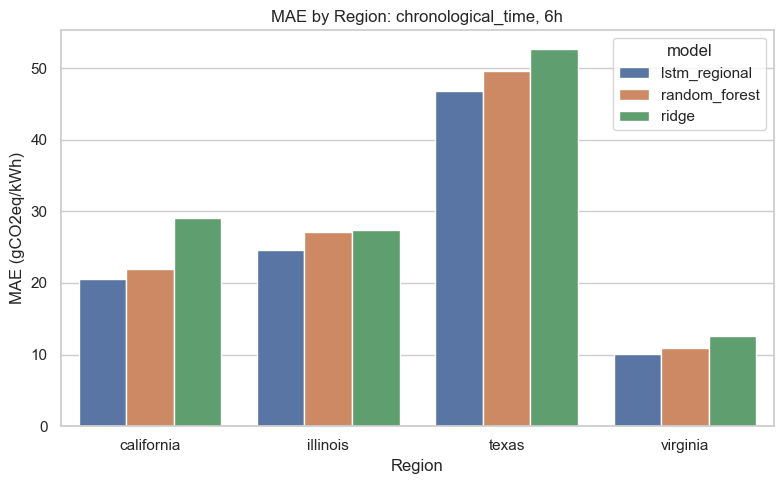

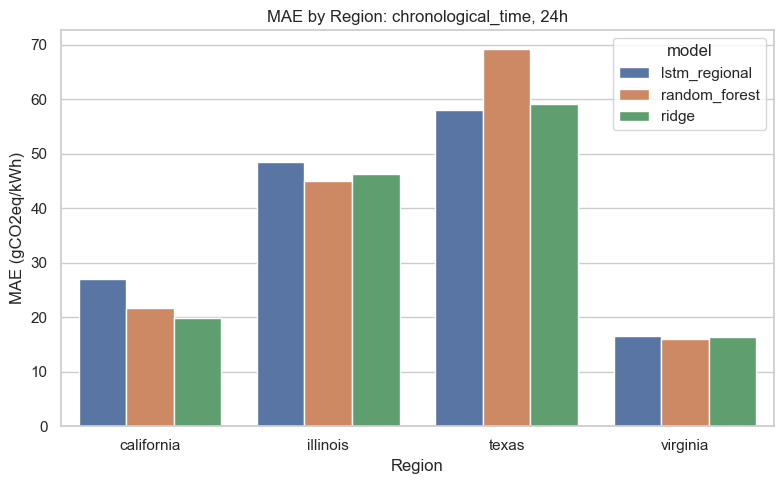

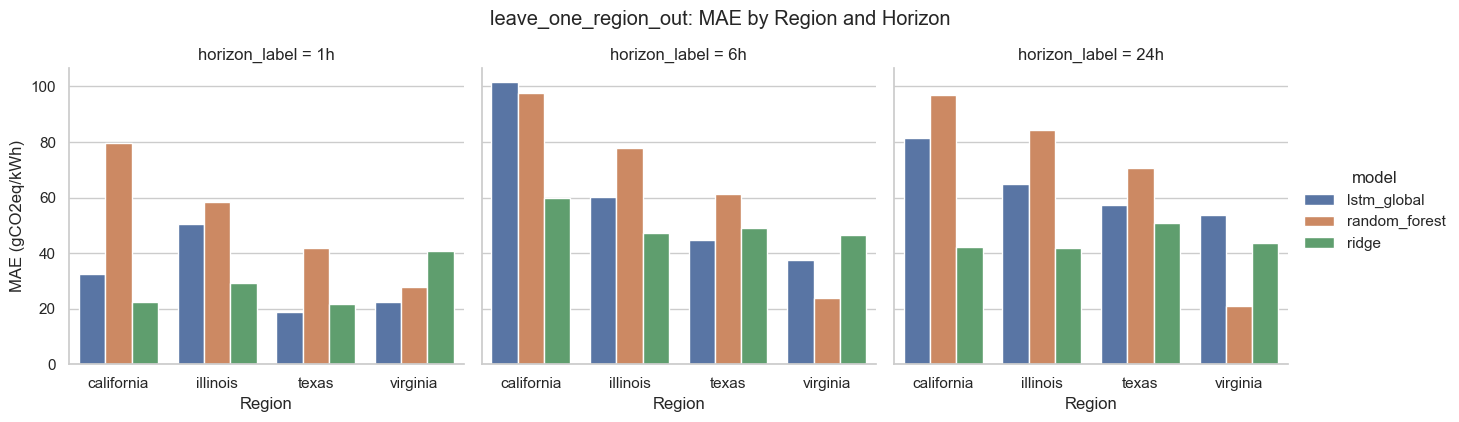

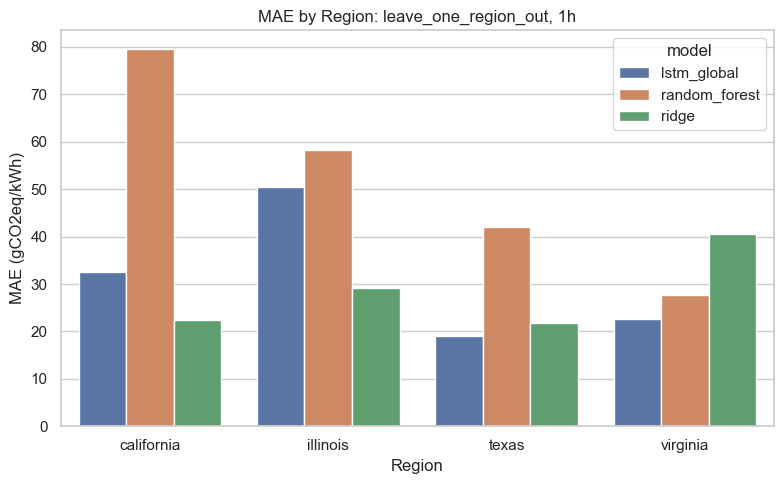

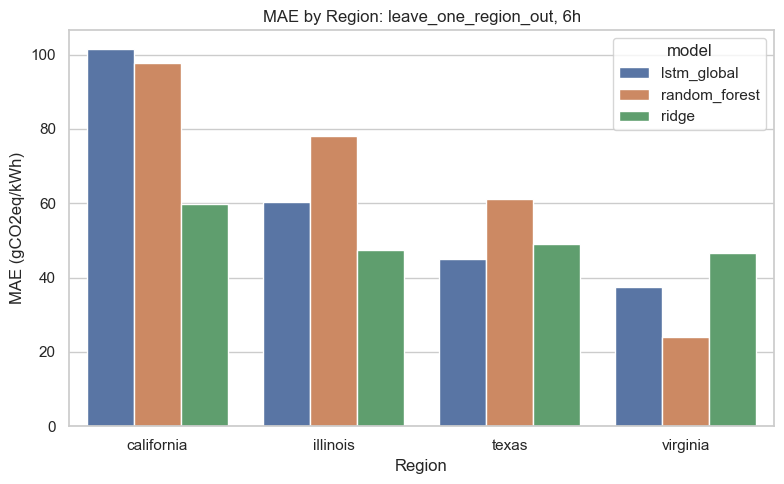

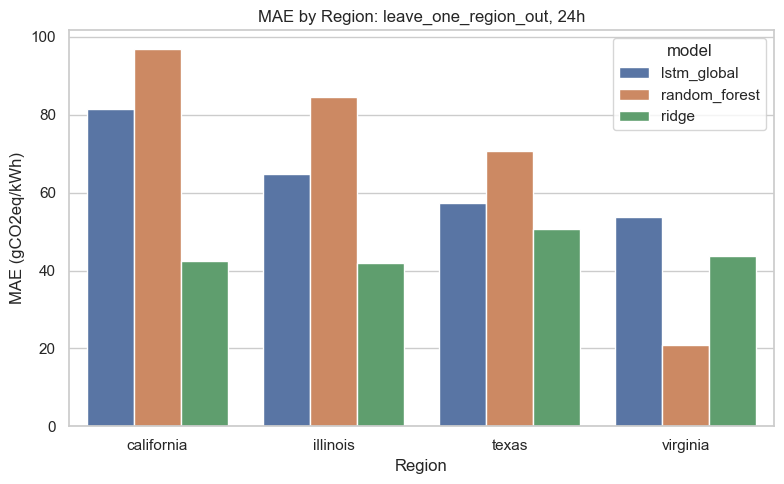

In [15]:
# Plot MAE by region to expose geography-specific strengths and weaknesses.
region_metrics = metrics[metrics["region"] != "macro_average"].copy()
if not region_metrics.empty:
    for split_type in sorted(region_metrics["split_type"].unique()):
        viz = region_metrics[region_metrics["split_type"] == split_type]
        g = sns.catplot(
            data=viz,
            x="region",
            y="MAE",
            hue="model",
            col="horizon_label",
            kind="bar",
            height=4,
            aspect=1.1,
        )
        g.set_axis_labels("Region", f"MAE ({UNIT})")
        g.fig.suptitle(f"{split_type}: MAE by Region and Horizon", y=1.05)
        plt.show()

        for horizon in HORIZONS:
            horizon_viz = viz[viz["horizon"] == horizon]
            if horizon_viz.empty:
                continue
            plt.figure(figsize=(8, 5))
            sns.barplot(data=horizon_viz, x="region", y="MAE", hue="model")
            plt.title(f"MAE by Region: {split_type}, {horizon}h")
            plt.xlabel("Region")
            plt.ylabel(f"MAE ({UNIT})")
            plt.tight_layout()
            plt.show()


## Graph: Regional Generalization Gap

The gap is `leave_one_region_out_MAE - chronological_time_MAE`. A smaller positive gap means the model loses less performance when moving from familiar regions to unseen regions.

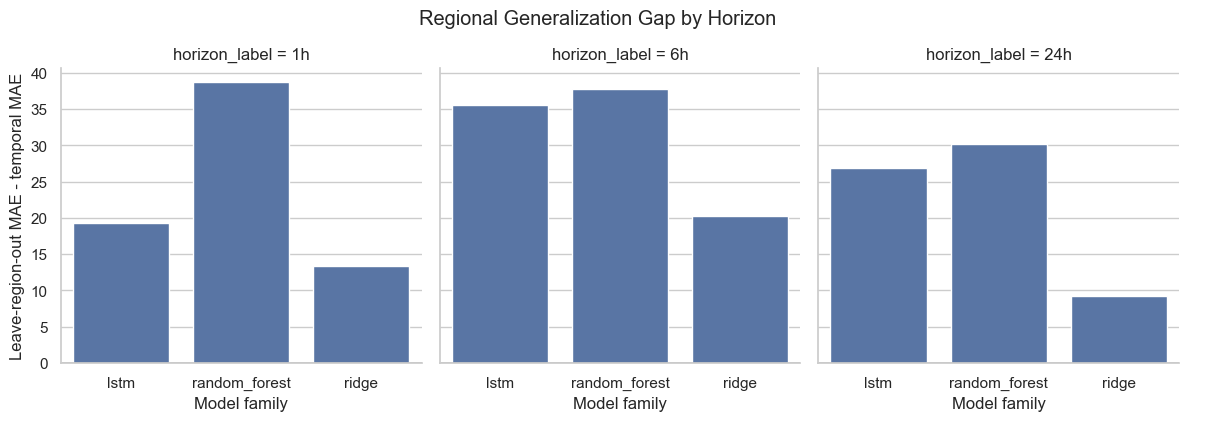

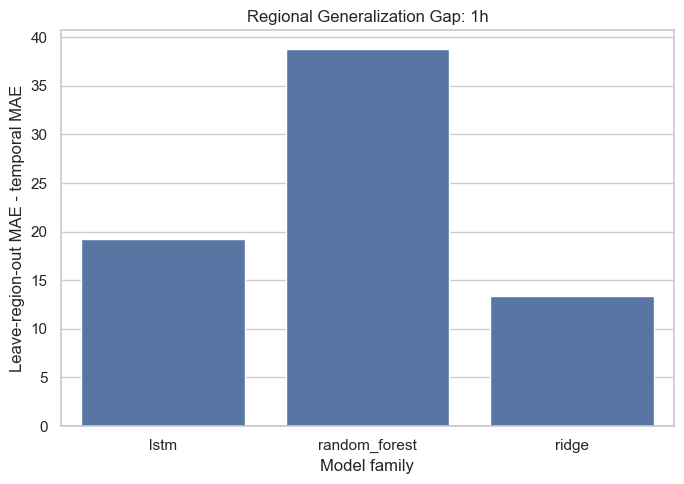

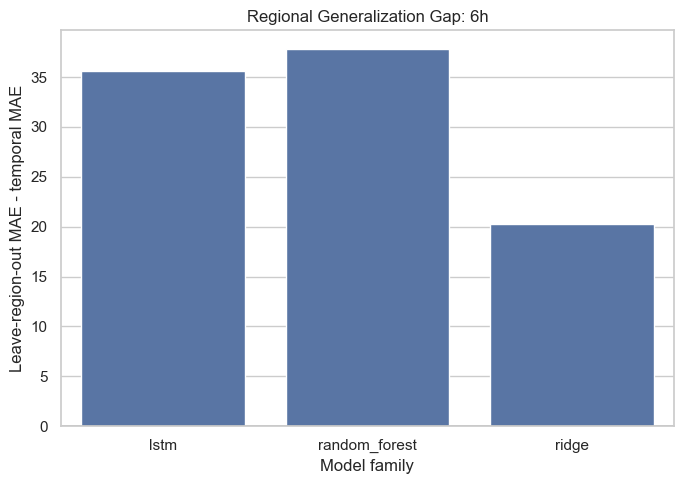

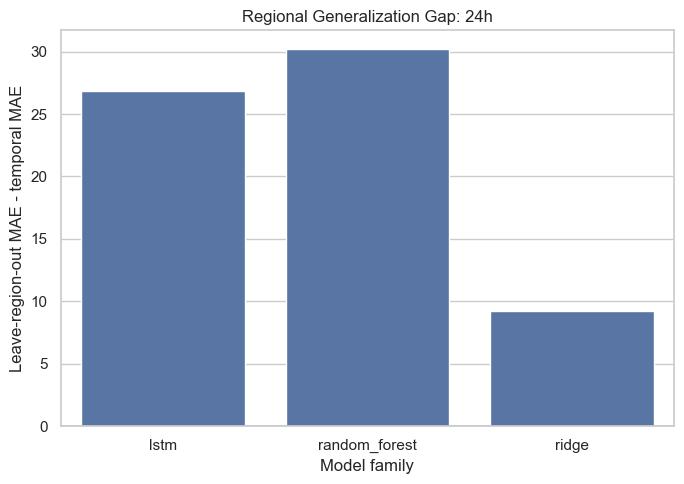

In [16]:
# Plot macro regional generalization gaps by model family and horizon.
if not macro_gaps.empty:
    macro_gaps["horizon_label"] = macro_gaps["horizon"].astype(str) + "h"
    g = sns.catplot(
        data=macro_gaps,
        x="model_family",
        y="region_gap",
        col="horizon_label",
        kind="bar",
        height=4,
        aspect=1,
    )
    g.set_axis_labels("Model family", "Leave-region-out MAE - temporal MAE")
    g.fig.suptitle("Regional Generalization Gap by Horizon", y=1.05)
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
    plt.show()

    for horizon in HORIZONS:
        viz = macro_gaps[macro_gaps["horizon"] == horizon]
        if viz.empty:
            continue
        plt.figure(figsize=(7, 5))
        sns.barplot(data=viz, x="model_family", y="region_gap")
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"Regional Generalization Gap: {horizon}h")
        plt.ylabel("Leave-region-out MAE - temporal MAE")
        plt.xlabel("Model family")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping gap plot until comparable temporal and regional rows exist.")


## Graph: Region-Specific Generalization Gap

This graph shows the same gap by individual region. It helps identify whether a model transfers poorly everywhere or whether the generalization problem is concentrated in specific held-out regions.

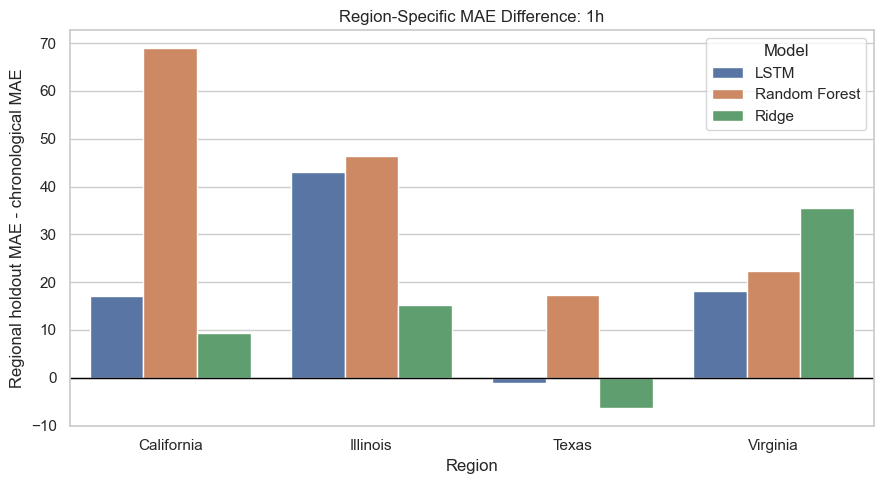

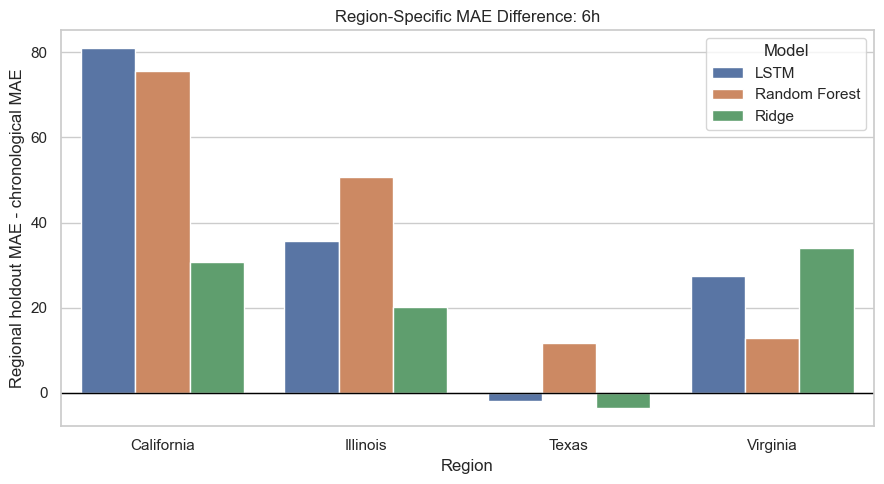

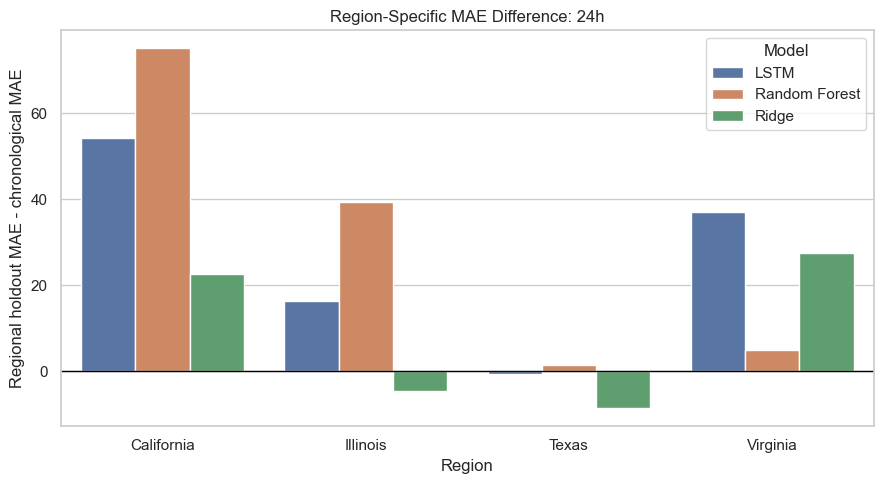

In [17]:
# Plot region-specific generalization gaps by horizon.
if "region_gap_table" in globals() and not region_gap_table.empty:
    plot_gap = region_gap_table.copy()
    plot_gap["Horizon"] = pd.Categorical(plot_gap["Horizon"], categories=["1h", "6h", "24h"], ordered=True)
    for horizon in ["1h", "6h", "24h"]:
        viz = plot_gap[plot_gap["Horizon"] == horizon]
        if viz.empty:
            continue
        plt.figure(figsize=(9, 5))
        sns.barplot(data=viz, x="Region", y="Difference", hue="Model")
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"Region-Specific MAE Difference: {horizon}")
        plt.ylabel("Regional holdout MAE - chronological MAE")
        plt.xlabel("Region")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping region-specific gap graph until comparable temporal and regional rows exist.")


## Graph: Predicted vs Actual

These diagnostic scatter plots check calibration. Points near the diagonal mean forecasts match actual values; systematic flattening or off-diagonal patterns suggest underprediction, overprediction, or compression toward the mean.

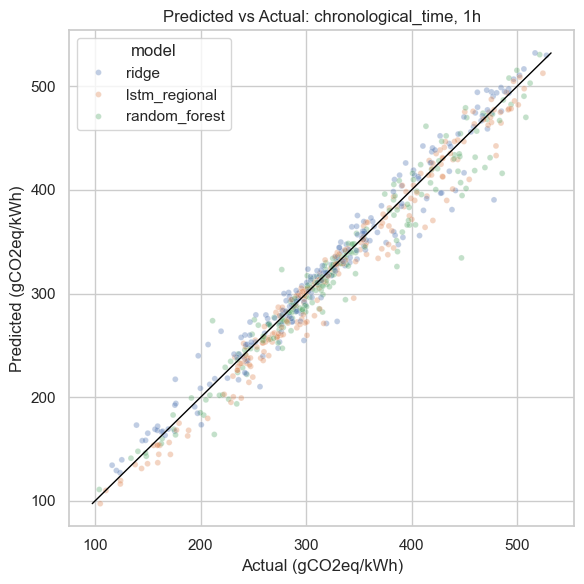

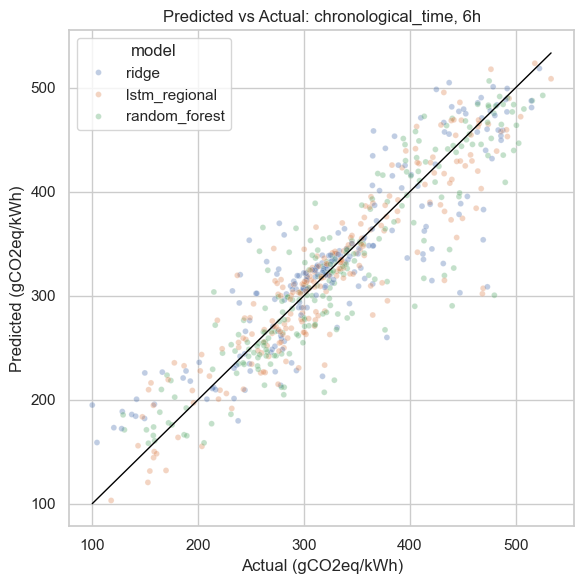

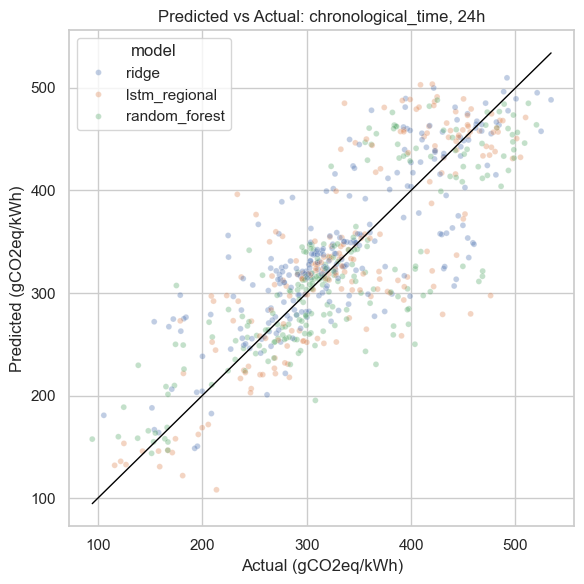

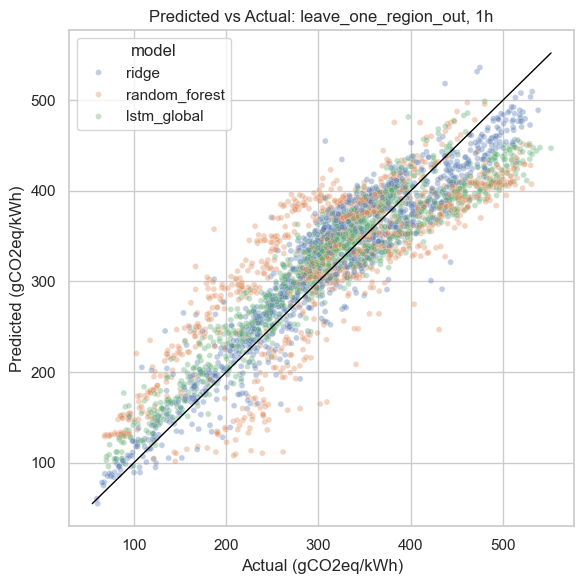

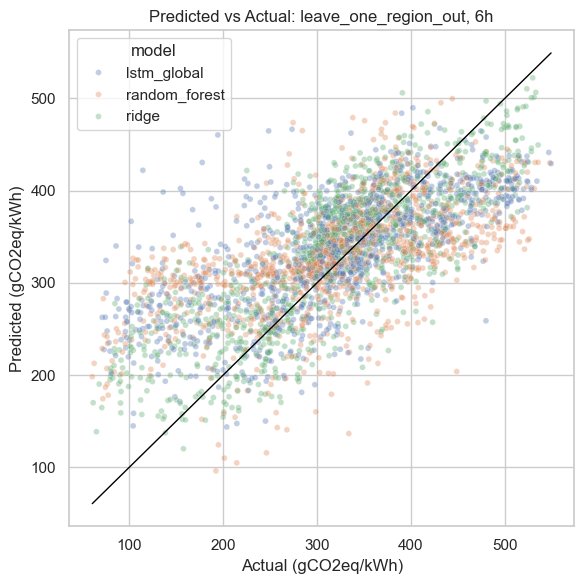

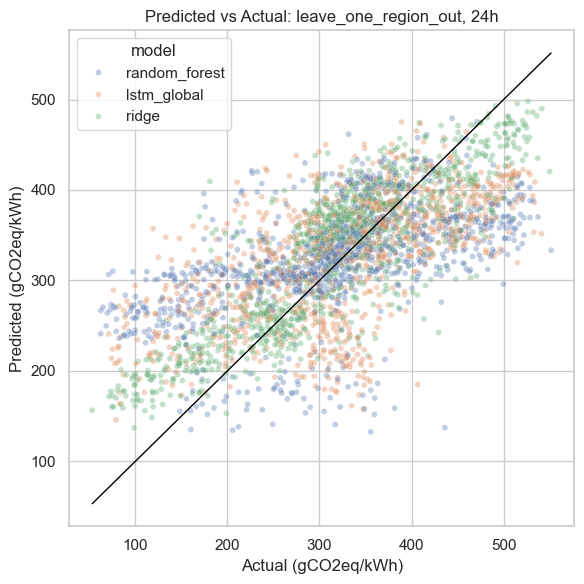

In [18]:
# Plot sampled predictions against actuals to inspect calibration and range compression.
sample = predictions.sample(min(12000, len(predictions)), random_state=42).copy()
sample["horizon_label"] = sample["horizon"].astype(str) + "h"
for split_type in sorted(sample["split_type"].unique()):
    for horizon in HORIZONS:
        viz = sample[(sample["split_type"] == split_type) & (sample["horizon"] == horizon)]
        if viz.empty:
            continue
        plt.figure(figsize=(6, 6))
        sns.scatterplot(data=viz, x="y_true", y="y_pred", hue="model", alpha=0.35, s=18)
        low = min(viz["y_true"].min(), viz["y_pred"].min())
        high = max(viz["y_true"].max(), viz["y_pred"].max())
        plt.plot([low, high], [low, high], color="black", linewidth=1)
        plt.title(f"Predicted vs Actual: {split_type}, {horizon}h")
        plt.xlabel(f"Actual ({UNIT})")
        plt.ylabel(f"Predicted ({UNIT})")
        plt.tight_layout()
        plt.show()


## Graph: Residual Distribution

Residuals are `prediction - actual`. A distribution centered near zero indicates low bias, while wide or skewed tails show large misses or systematic over/underprediction.

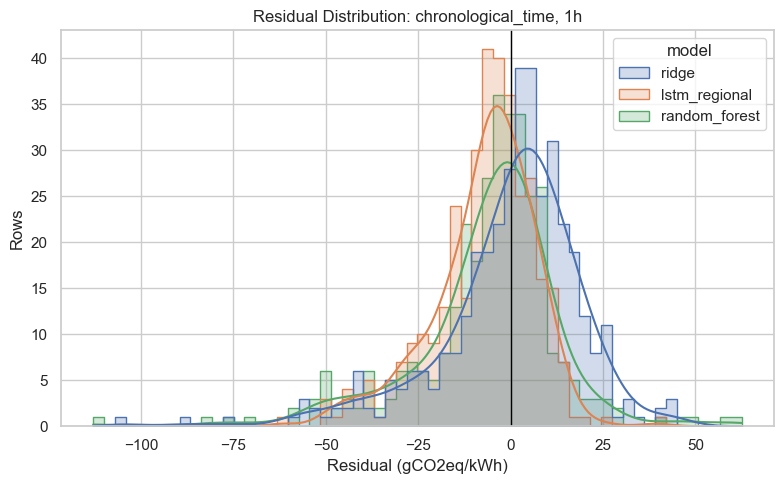

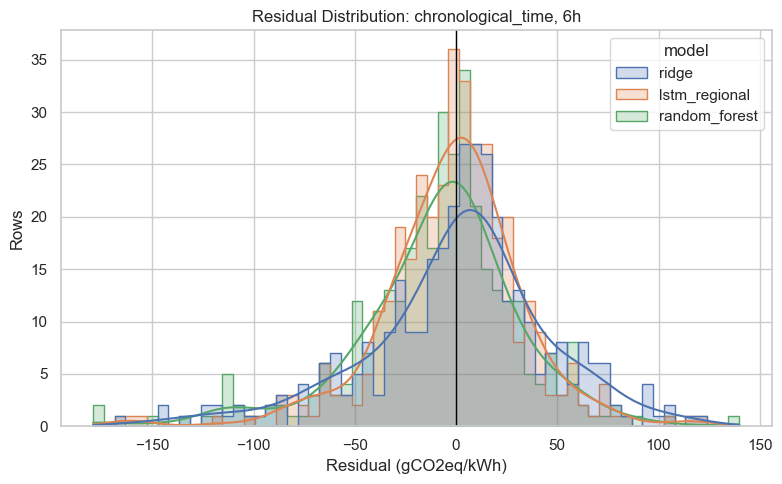

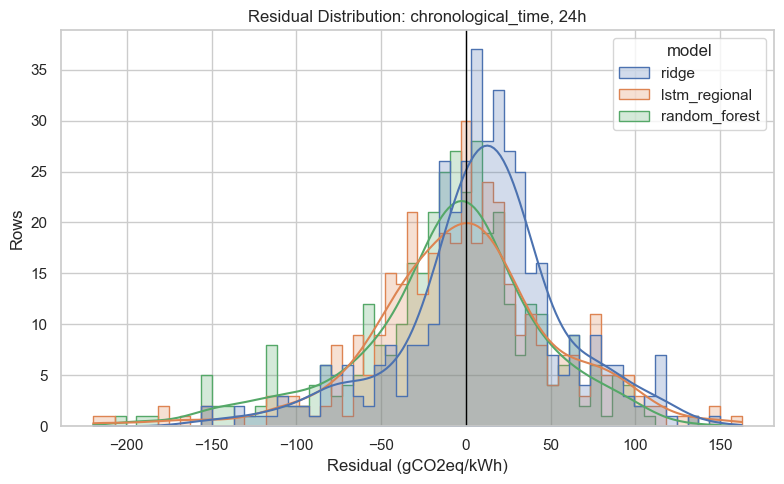

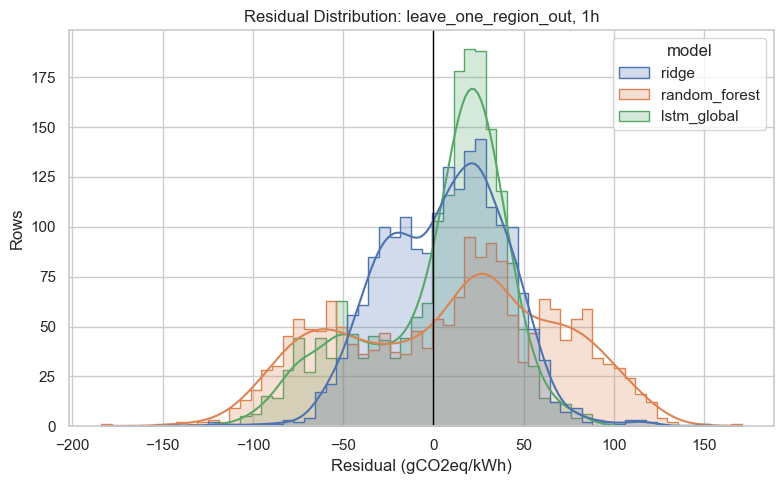

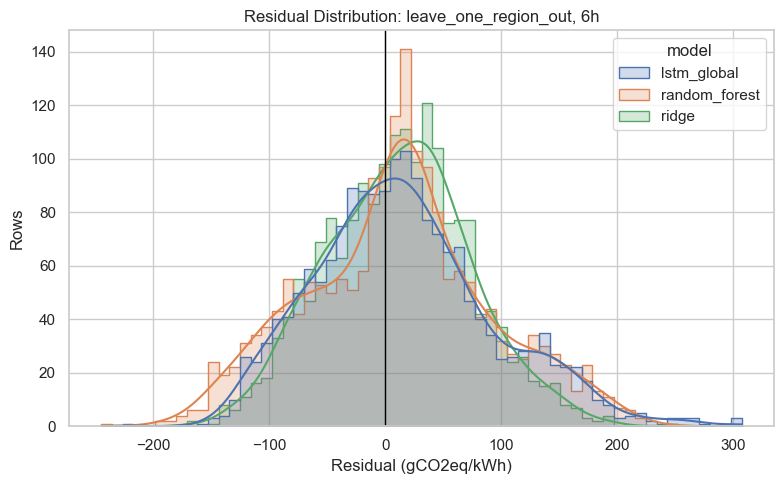

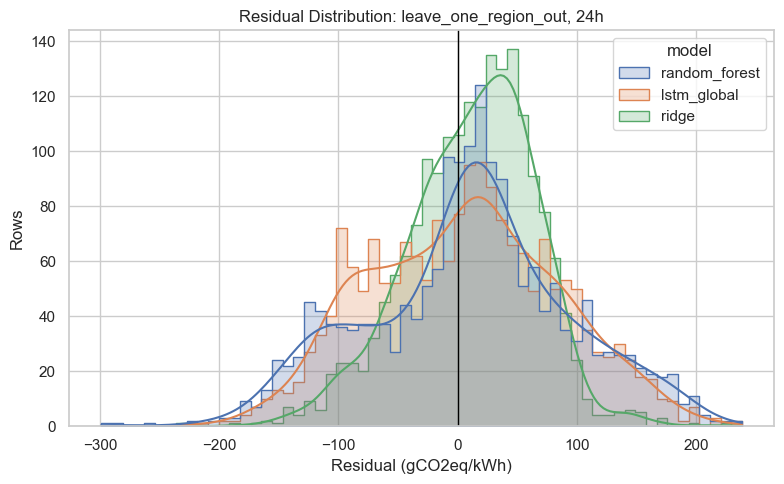

In [19]:
# Plot residual distributions to inspect bias and tail errors.
residuals = predictions.copy()
residuals["residual"] = residuals["y_pred"] - residuals["y_true"]
residuals["horizon_label"] = residuals["horizon"].astype(str) + "h"
residuals = residuals.sample(min(20000, len(residuals)), random_state=42)

for split_type in sorted(residuals["split_type"].unique()):
    for horizon in HORIZONS:
        viz = residuals[(residuals["split_type"] == split_type) & (residuals["horizon"] == horizon)]
        if viz.empty:
            continue
        plt.figure(figsize=(8, 5))
        sns.histplot(data=viz, x="residual", hue="model", bins=60, kde=True, element="step", stat="count")
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Residual Distribution: {split_type}, {horizon}h")
        plt.xlabel(f"Residual ({UNIT})")
        plt.ylabel("Rows")
        plt.tight_layout()
        plt.show()


## Graph: Actual vs Predicted Time-Series Examples

These examples show whether each model follows the shape of carbon-intensity changes through time. They are qualitative diagnostics, not the official metric summary.

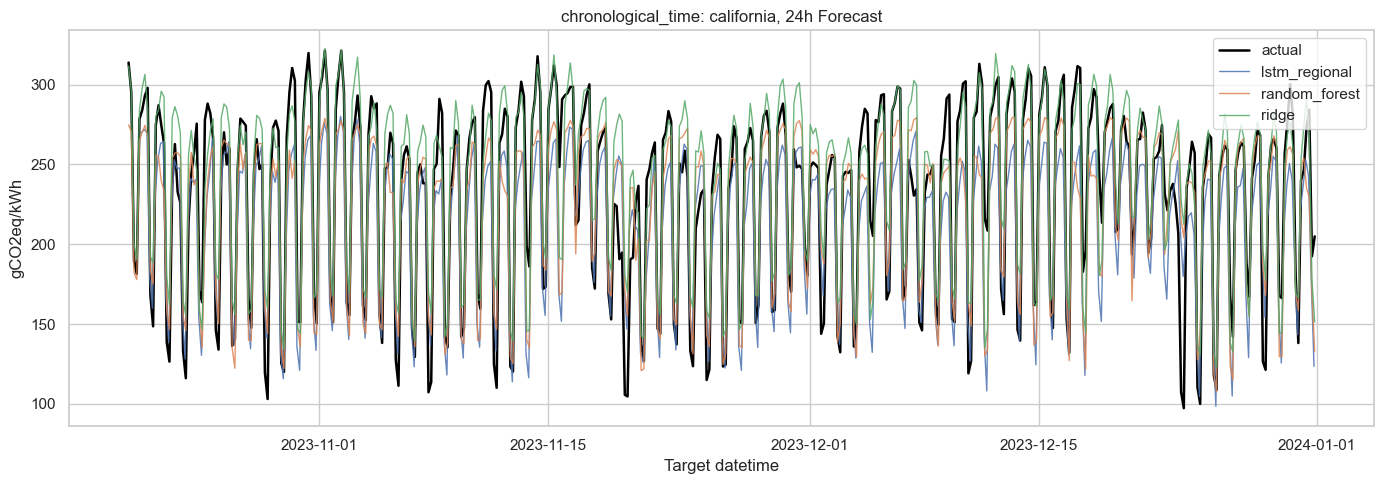

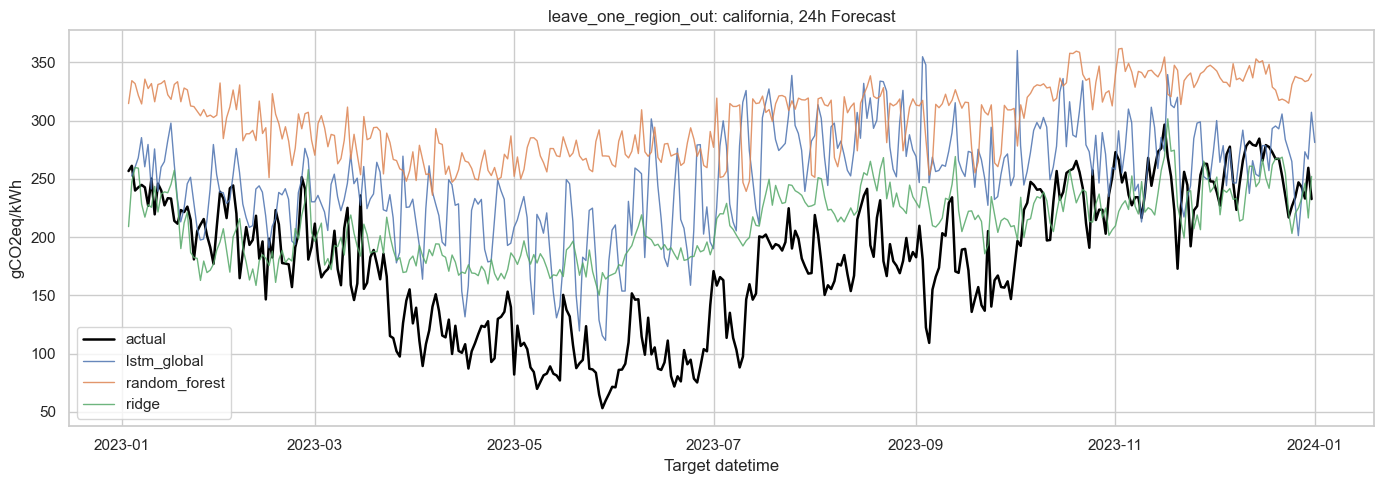

In [20]:
# Plot example time series to visually compare forecast shape against actual values.
for split_type in sorted(predictions["split_type"].unique()):
    split_data = predictions[predictions["split_type"] == split_type].copy()
    if split_data.empty:
        continue
    horizon = max(split_data["horizon"].unique())
    region = sorted(split_data["region"].unique())[0]
    viz = split_data[(split_data["horizon"] == horizon) & (split_data["region"] == region)].sort_values("target_datetime")
    if viz.empty:
        continue

    plt.figure(figsize=(14, 5))
    actual = viz.drop_duplicates(["target_datetime", "region", "horizon"])
    step = max(1, len(actual) // 350)
    plt.plot(actual["target_datetime"].iloc[::step], actual["y_true"].iloc[::step], color="black", linewidth=1.8, label="actual")

    for model_name, model_frame in viz.groupby("model"):
        step = max(1, len(model_frame) // 350)
        plt.plot(model_frame["target_datetime"].iloc[::step], model_frame["y_pred"].iloc[::step], linewidth=1, alpha=0.85, label=model_name)

    plt.title(f"{split_type}: {region}, {horizon}h Forecast")
    plt.ylabel(UNIT)
    plt.xlabel("Target datetime")
    plt.legend()
    plt.tight_layout()
    plt.show()
